In [285]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import plot_importance
from tabulate import tabulate
from sklearn.feature_extraction.text import CountVectorizer
from nltk.tokenize import RegexpTokenizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn import metrics
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from datetime import datetime
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from sklearn.model_selection import train_test_split, GridSearchCV
from itertools import product



import warnings 
warnings.filterwarnings('ignore')

In [287]:
df = pd.read_csv('eu_merged.csv')
df.head(2)

,Country Name,Country Code,Year,Electric Power Consumption,Energy use
0,Austria,AUT,1960,1814.676017,1546.261468
1,Austria,AUT,1961,1882.223711,1554.034906


In [156]:
df.isnull().sum()

Country Name                    0
Country Code                    0
Year                            0
Electric Power Consumption    221
Energy use                    221
dtype: int64

In [157]:
#filtered_df = df[df['Year'] >= 1990]
#filtered_df.reset_index(drop=True)

In [158]:
df.isnull().sum()

Country Name                    0
Country Code                    0
Year                            0
Electric Power Consumption    221
Energy use                    221
dtype: int64

In [159]:
df.dtypes

Country Name                   object
Country Code                   object
Year                            int64
Electric Power Consumption    float64
Energy use                    float64
dtype: object

In [160]:
df.columns

Index(['Country Name', 'Country Code', 'Year', 'Electric Power Consumption',
       'Energy use'],
      dtype='object')

### Plotting distribution

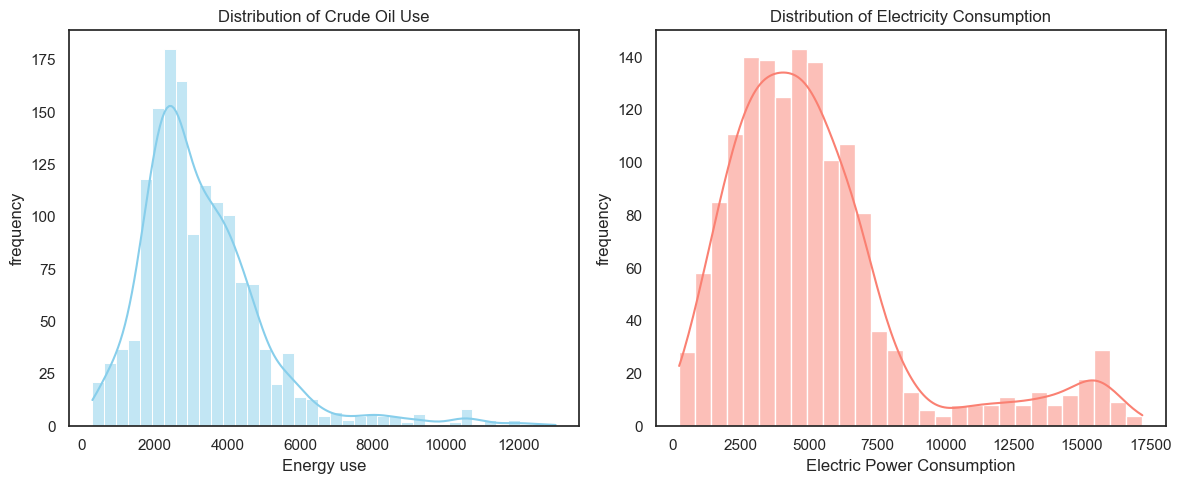

In [162]:
# Set style
sns.set(style="white")

# Plot histograms
plt.figure(figsize=(12, 5))

# Crude Oil Use
plt.subplot(1, 2, 1)
sns.histplot(data=df, x="Energy use", kde=True, color="skyblue")
plt.title("Distribution of Crude Oil Use")
plt.ylabel('frequency')

# Electricity Consumption
plt.subplot(1, 2, 2)
sns.histplot(data=df, x="Electric Power Consumption", kde=True, color="salmon")
plt.title("Distribution of Electricity Consumption")
plt.ylabel('frequency')

plt.tight_layout()
#plt.savefig('Histograms_eu.png')
plt.show()

Crude oil (Energy use): The distribution of crude oil consumption is positive skewed. This means that the tail of the distribution moves further to the right (higher energy use values).
The majority of the observations are focused at low to moderate crude oil use, with an x-axis peak between 2000 and 3000.

Electricity Consumption: The distribution of electricity consumption is complex and multimodal, with a moderate peak between 4000 and 6000, a skewed distribution suggesting lower frequency, and a smaller secondary peak around 16000-17000. The frequency drops between the main peak and secondary peak.


In [164]:
# Replace missing numeric values with median
numeric_cols = df.select_dtypes(include=[np.number]).columns
for col in numeric_cols:
    median_value = df[col].median()
    df[col].fillna(median_value, inplace=True)

Since two datasets have right-skewed distribution, the project imputes the missing values with median. 

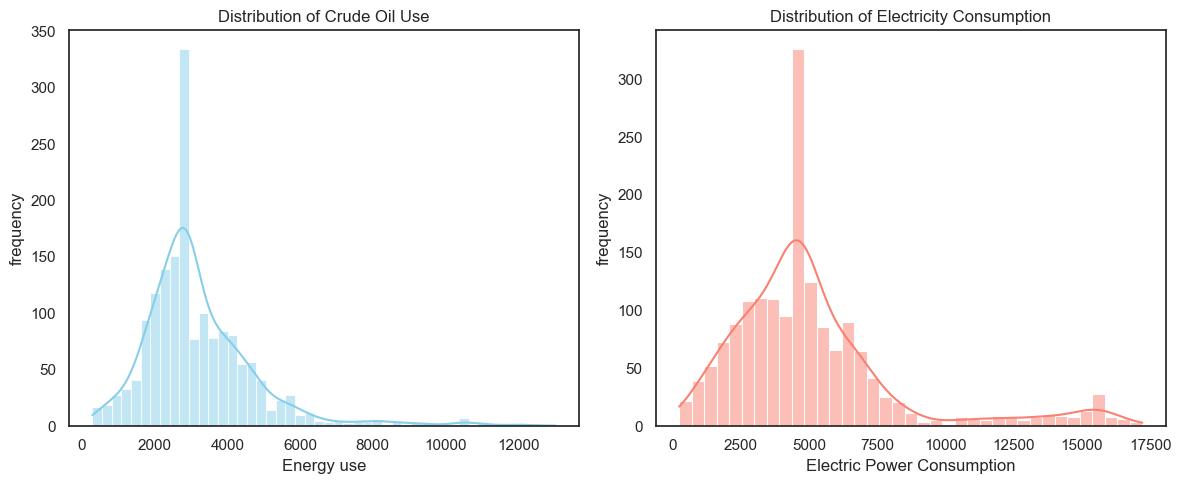

In [166]:
# Set style
sns.set(style="white")

# Plot histograms
plt.figure(figsize=(12, 5))

# Crude Oil Use
plt.subplot(1, 2, 1)
sns.histplot(data=df, x="Energy use", kde=True, color="skyblue")
plt.title("Distribution of Crude Oil Use")
plt.ylabel('frequency')

# Electricity Consumption
plt.subplot(1, 2, 2)
sns.histplot(data=df, x="Electric Power Consumption", kde=True, color="salmon")
plt.title("Distribution of Electricity Consumption")
plt.ylabel('frequency')

plt.tight_layout()
plt.savefig('Histograms_transformed_eu.png')
plt.show()

In [167]:
missing_counts = df.isnull().sum()
print("Missing values in each column:")
print(missing_counts)

Missing values in each column:
Country Name                  0
Country Code                  0
Year                          0
Electric Power Consumption    0
Energy use                    0
dtype: int64


### Research question: Does crude oil use influence electricity consumption in a given time period in EU?"

In [169]:
# Split features and target variable
X = df[["Energy use"]]  # Independent variable
y = df["Electric Power Consumption"]  # Dependent variable                         

In [170]:
# Split the data into training and testing sets and write the random_state value
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [171]:
# Models
models = {
    "XGB": XGBRegressor(),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    }

The project chooses tree-based models for our research question. 

**XGB:** The project aims to see how one variable is related to another variable. Linear Regression should be applied to answer the research question. However, the data we are working with does not follow the normality assumption that Linear Regression needs. Therefore, the tree-based models such as XGB and Random Forest are applied. XGB utilizes decision trees as base learners and employs regularization techniques to enhance model generalization ([Aayush Tyagi ,2025](https://www.analyticsvidhya.com/blog/2018/09/an-end-to-end-guide-to-understand-the-math-behind-xgboost/)). The algorithm works by sequentially adding weak learners to the ensemble, with each new learner focusing on correcting the errors made by the existing ones. 

**Random Forest:** Random Forest is a non-linear model that can capture complex non-linear relationships between crude oil use and electricity consumption. It is tree-based structure with multiple decision trees. By averaging the results from multiple trees, Random Forest reduces the variance and improves the robustness of the predictions([Sruthi,2025](https://www.analyticsvidhya.com/blog/2021/06/understanding-random-forest/)). Therefore, random forest algorithm is applied in this project because we are working with the skewed dataset. Additionally, Random Forest doesn't assume a linear relationship between independent and dependent variables, making it suitable for exploring complex associations. 

#### Model Evaluation

In [174]:
# Store results
results = []
feature_importance_dfs = []

# Train and evaluate models
for name, model in models.items():
    # Train the model
    model.fit(X_train, y_train)
    
    # Predict on the test set
    y_pred = model.predict(X_test)
    
    # Calculate performance metrics
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    
    # Append results to the list
    results.append([name, mae, mse, rmse, r2])

    importance = model.feature_importances_  
    fi_df = pd.DataFrame({
        'Feature': X_train.columns,
        'Importance': importance,
        'Model': name
    }).sort_values('Importance', ascending=False)
    feature_importance_dfs.append(fi_df)
    
# Create a DataFrame to display the results
results_df = pd.DataFrame(results, columns=["Model", "MAE", "MSE", "RMSE", "R2 Score"])
print(tabulate(results_df, headers='keys', tablefmt='grid', showindex=False))
print("\n=== Feature Importance ===")
for fi_df in feature_importance_dfs:
    print(f"\nModel: {fi_df['Model'].iloc[0]}")
    print(tabulate(fi_df, headers='keys', tablefmt='grid', showindex=False))

+---------------+---------+-------------+---------+------------+
| Model         |     MAE |         MSE |    RMSE |   R2 Score |
+===============+=========+=============+=========+============+
| XGB           | 1127.91 | 2.6205e+06  | 1618.79 |   0.790928 |
+---------------+---------+-------------+---------+------------+
| Random Forest | 1235.92 | 3.25323e+06 | 1803.67 |   0.740446 |
+---------------+---------+-------------+---------+------------+

=== Feature Importance ===

Model: XGB
+------------+--------------+---------+
| Feature    |   Importance | Model   |
+============+==============+=========+
| Energy use |            1 | XGB     |
+------------+--------------+---------+

Model: Random Forest
+------------+--------------+---------------+
| Feature    |   Importance | Model         |
+============+==============+===============+
| Energy use |            1 | Random Forest |
+------------+--------------+---------------+


R² (R-squared) is a measure of how well the model explains the variability of the target variable. R² = 1 indicates a perfect model where predictions fit the data perfectly. R² = 0 means that the model performs no better than predicting the mean of the target values. R² < 0 (negative R²) occurs when the model is performing worse than simply predicting the mean of the target for all data points (Dr Muhammad Iqbal, 2025).

**Comparative insights:** 

The XGB model has a lower MAE (1127) compared to the Linear Regression model (1235), suggesting closer predictions. It also has a lower MSE (2.62 x 10^6), suggesting fewer large errors than Random Forest. The RMSE (1618) is lower, indicating a typical prediction error of 1618 units of electricity consumption. The model achieves higher R2 score, explaining 79% explaining in variance in data. 

The Random Forest model, with a R2 score (74.04%), is effective in explaining the variance with 1803 error in predicting the electricity consumption.

### Cross validation scores of different models

In [177]:
# Store results
results = []

# Train and evaluate models using cross-validation for R² Score
for name, model in models.items():
    # Perform cross-validation
    cv_scores = cross_val_score(model, X, y, cv=5, scoring='r2')  # Using R² for scoring
    mean_cv_score = cv_scores.mean()  # Mean R² score
    
    # Train the model on the full dataset for predictions
    model.fit(X, y)
    
    # Store results
    results.append([name, mean_cv_score])

# Create a DataFrame to display the results
results_df = pd.DataFrame(results, columns=["Model", "Mean CV R² Score"])
print("\nModel Performance Metrics using five-fold cross-validation for R² Score:")
print(results_df)


Model Performance Metrics using five-fold cross-validation for R² Score:
           Model  Mean CV R² Score
0            XGB          0.525415
1  Random Forest          0.438136


**Interpretation:**

We use the cross-validation to see how well the model is performing in the unseen data.

K-Fold Cross-Validation provides a more robust and reliable performance estimate because it reduces the impact of data variability ([Chugani,2024](https://www.datacamp.com/tutorial/k-fold-cross-validation)).
    
Using several training and testing cycles reduces the possibility of overfitting to a certain data split. This strategy also assures that every data point is considered for training and validation, resulting in a more thorough evaluation of the model's performance. 

The project use five and ten folds to witness the variation in model performance. The cross vaildation with five folds is set to have a balance between bias and computational cost. 

The mean cross-validation score of the XGB is better than Random Forest Regressor. The model explains 53% of electricity consumption variance, indicating a moderate positive relationship between independent variables, but leaving 47% of variance unexplained.

The Random Forest model, on average, explains 43.81% of electricity consumption variance across five cross-validation folds. However, it has a slightly lower mean R² score compared to the XGB model, 57% of variance unexplained.

In [179]:
# Store results
results = []

# Train and evaluate models using cross-validation for R² Score
for name, model in models.items():
    # Perform cross-validation
    cv_scores = cross_val_score(model, X, y, cv=10, scoring='r2')  # Using R² for scoring
    mean_cv_score = cv_scores.mean()  # Mean R² score
    
    # Train the model on the full dataset for predictions
    model.fit(X, y)
    
    # Store results
    results.append([name, mean_cv_score])

# Create a DataFrame to display the results
results_df = pd.DataFrame(results, columns=["Model", "Mean CV R² Score"])
print(f"\nModel Performance Metrics using ten-fold Cross-Validation for R² Score:")
print(results_df)


Model Performance Metrics using ten-fold Cross-Validation for R² Score:
           Model  Mean CV R² Score
0            XGB          0.269649
1  Random Forest          0.112748


**Interpretation:**

We use ten-fold cross-validation to see the variation between five folds and ten folds. 

The XGB model explains 27% of electricity consumption variance, but it can take more time for a computer to load results. However, 10 fold can give less bias as as we increase folds and train more time to evaluate the results. 

The Random Forest model, which accounts for 11.27% of variance, is deemed poorly performing due to its weak generalization performance, as indicated by its ten-fold CV result.

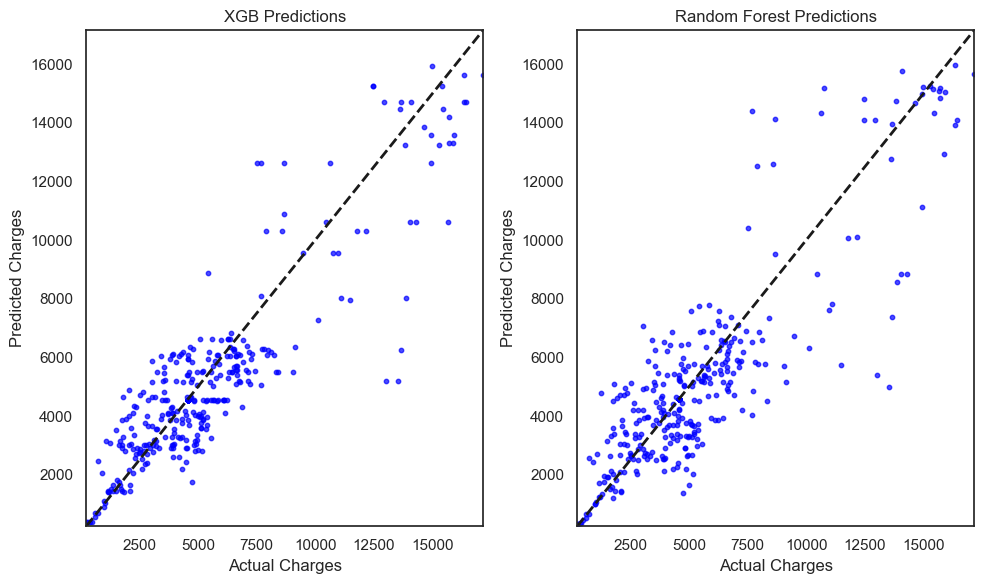

In [181]:
# Split the data

X = df[["Energy use"]]  # Independent variable
y = df["Electric Power Consumption"]  # Dependent variable    

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Predict on the test set for final evaluation
predictions = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    predictions[name] = y_pred

# Plotting actual vs predicted for each model in a 3x2 grid
plt.figure(figsize=(10, 6))  # Adjusted size for a 3x2 layout

for i, (name, y_pred) in enumerate(predictions.items()):
    plt.subplot(1, 2, i +1)  # 1 rows and 2 columns
    plt.scatter(y_test, y_pred, alpha=0.7, color='blue', s=10)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)  # Diagonal line
    plt.title(f'{name} Predictions')
    plt.xlabel('Actual Charges')
    plt.ylabel('Predicted Charges')
    plt.xlim(y_test.min(), y_test.max())
    plt.ylim(y_test.min(), y_test.max())

plt.tight_layout()
#plt.savefig('Pred_charges_eu_untuned.png')
plt.show()

**Interpretation:**

The scatterplot is plotted to carry out the visual assessment of the two models' performance to see whether the model predict or underpredit. 

In this graph, each blue dot represents the association between the actual charge and the charge predicted by the Linear Regression model for a given data point. Black line is a perfect prediction. If all of the blue dots fell perfectly on this line, the model's predictions would always be exactly the same as the actual values.

XGB: The model's predictions show a positive trend as actual charges increase, but the wide spread of points, particularly at higher actual charges. The error is less prone in XGB than Random Forest. 

Random Forest: The Random Forest model's perform nearly well together with  egression model, with points clustered around the dashed black line. It has lower prediction errors and less tendency to underpredict at high and overpredict at low charges. Despite some scatter, its predictions are closer to actual values.

### Hyperparameter Tunnning using GridSearchCV

In [184]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor
import numpy as np
import pandas as pd

# Define features and target variable
X = df[["Energy use"]]  # Independent variable
y = df["Electric Power Consumption"]  # Dependent variable    

# Set up parameter grids for each model
param_grid = {
    'XGB': {
        'n_estimators': [100, 200],
        'learning_rate': [0.05, 0.1],
        'max_depth': [3, 5],
        'subsample': [0.8, 1.0],
        'colsample_bytree': [0.8],
        'gamma': [0, 0.1],
        'reg_lambda': [1, 10]
    },
    'Random Forest': {
        'n_estimators': [50, 100, 200],
        'max_depth': [None, 5, 10]
    }
}

# Initialize results
results = []
predictions = {}

# Define models
models = {
    "XGB": XGBRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42)
}

# Train and tune models
for name, model in models.items():
    grid_search = GridSearchCV(model, param_grid[name], cv=10, scoring='r2', return_train_score=True)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    grid_search.fit(X_train, y_train)
    
    # Get best model and predictions
    best_model = grid_search.best_estimator_
    y_pred = best_model.predict(X_test)
    y_train_pred = best_model.predict(X_train)  # Training predictions
    
    # Calculate metrics
    metrics = {
        'Model': name,
        'Best Parameters': grid_search.best_params_,
        'Best CV R² Score': grid_search.best_score_,
        'Train R²': r2_score(y_train, y_train_pred),  # Training R²
        'Test R²': r2_score(y_test, y_pred),          # Test R²
        'Train MAE': mean_absolute_error(y_train, y_train_pred),  # Training MAE
        'Test MAE': mean_absolute_error(y_test, y_pred),          # Test MAE
        'Train RMSE': np.sqrt(mean_squared_error(y_train, y_train_pred)),  # Training RMSE
        'Test RMSE': np.sqrt(mean_squared_error(y_test, y_pred)),          # Test RMSE
        'Train MSE': mean_squared_error(y_train, y_train_pred),  # Training MSE
        'Test MSE': mean_squared_error(y_test, y_pred)           # Test MSE
    }
    
    results.append(metrics)
    predictions[name] = y_pred

# Create DataFrame
results_df = pd.DataFrame(results)

# Display full results without truncation
pd.set_option('display.max_columns', None)
pd.set_option('display.expand_frame_repr', False)
pd.set_option('display.max_colwidth', None)

print("\nModel Evaluation Results:")
display(results_df)


Model Evaluation Results:


,Model,Best Parameters,Best CV R² Score,Train R²,Test R²,Train MAE,Test MAE,Train RMSE,Test RMSE,Train MSE,Test MSE
0,XGB,"{'colsample_bytree': 0.8, 'gamma': 0, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100, 'reg_lambda': 10, 'subsample': 0.8}",0.791139,0.826683,0.812000,894.995415,1079.096923,1289.709008,1535.047933,1.663349e+06,2.356372e+06
1,Random Forest,"{'max_depth': 5, 'n_estimators': 200}",0.792916,0.851601,0.803201,846.357096,1091.077827,1193.401533,1570.561411,1.424207e+06,2.466663e+06


In [185]:
df.shape

(1701, 5)

**Grid Search CV:** 

Hyperparameters: 

We applied minimal hyperparameters to minimize computing time and power and yield better accuracy score. 

Ten-fold cross vaildation is applied to get more reliable estimate. Since our dataset has 1701 observations, which is moderate in size. We can also applied five folds as well as ten fold cross vaildation. To get precise estimation, we use ten-fold cross validation as each test fold in ten-fold CV uses 170 samples, than 340 samples.

XGB: 100 trees is found to be better than 200 trees. learning_rate is used to prevent overfitting. 0.05 learning rate is founded to be best parameter. We reduce the use of deeper trees to minimize CPU usage. 3 layers of trees are found to be best parameter. Only 80% of features be sampled for trees. 'gamma' parameter controls the minimum loss reduction required to make a further partition on a leaf node of a tree ([DataCamp,2020](https://campus.datacamp.com/courses/extreme-gradient-boosting-with-xgboost/regression-with-xgboost?ex=7)). Gamma (0) which means no pruning is best option. 


**Best CV R-square score:**

XGB: The five-fold cross vaildation of R2 score is 0.80.  with the best hyperparameters explains approximately 80% of the variance in the target variable. 

Random Forest: With max_depth=5 and n_estimators=200 across all five cross-validation folds, the Random Forest model explains approximately 79.5% of the variance in the target variable.

We can see that XGB slightly perform better than Random Forest after hyperparameter tuning.

In [187]:
# Define features and target variable
X = df[["Energy use"]]  # Independent variable
y = df["Electric Power Consumption"]  # Dependent variable    

# Set up parameter grids for each model
param_grid = {
    'XGB': {
        'n_estimators': [100, 200], #number of trees #common columns values
        'learning_rate': [0.05, 0.1], #step size to prevent overfitting
        'max_depth': [3, 5], #control tree depth
        'subsample': [0.8, 1.0], #Fraction of sample to be randomly sampled for each tree to reduce overfitting
        'colsample_bytree': [0.8], #Fraction of columns to be randomly sampled for each tree to reduce variance
        'gamma': [0, 0.1], #loss function: to make a further partition on a leaf node
        'reg_lambda': [1, 10] #L2 regularization term on weights 
    },
    'Random Forest': {
        'n_estimators': [50, 100, 200], ## Number of trees in the forest
        'max_depth': [None, 5, 10] #control tree depth
    }
}

# Initialize results list with correct columns
results = []
predictions = {}

# Define the models
models = {
    "XGB": XGBRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42)
}

# Train and tune models
for name, model in models.items():
    grid_search = GridSearchCV(model, param_grid[name], cv=5, scoring='r2')
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    grid_search.fit(X_train, y_train)
    
    # Get best model and predictions
    best_model = grid_search.best_estimator_
    y_pred = best_model.predict(X_test)
    
    # Calculate metrics
    metrics = {
        'Model': name,
        'Best Parameters': grid_search.best_params_,
        'Best CV R² Score': grid_search.best_score_,
        'Test R²': r2_score(y_test, y_pred),
        'MAE': mean_absolute_error(y_test, y_pred),
        'MSE': mean_squared_error(y_test, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred))
    }
    
    results.append(metrics)
    predictions[name] = y_pred

# Create DataFrame
results_df = pd.DataFrame(results)

# Display full results without truncation
pd.set_option('display.max_columns', None)
pd.set_option('display.expand_frame_repr', False)
pd.set_option('display.max_colwidth', None)

print("\nModel Evaluation Results with five folds:")
display(results_df)


Model Evaluation Results with five folds:


,Model,Best Parameters,Best CV R² Score,Test R²,MAE,MSE,RMSE
0,XGB,"{'colsample_bytree': 0.8, 'gamma': 0, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100, 'reg_lambda': 1, 'subsample': 0.8}",0.800773,0.811593,1077.283662,2.361484e+06,1536.712108
1,Random Forest,"{'max_depth': 5, 'n_estimators': 200}",0.795365,0.803201,1091.077827,2.466663e+06,1570.561411


After applying cross-validation with five folds, although random forest model outcomes does not change. XGB model has improved when cross-validation folds are reduced to five.

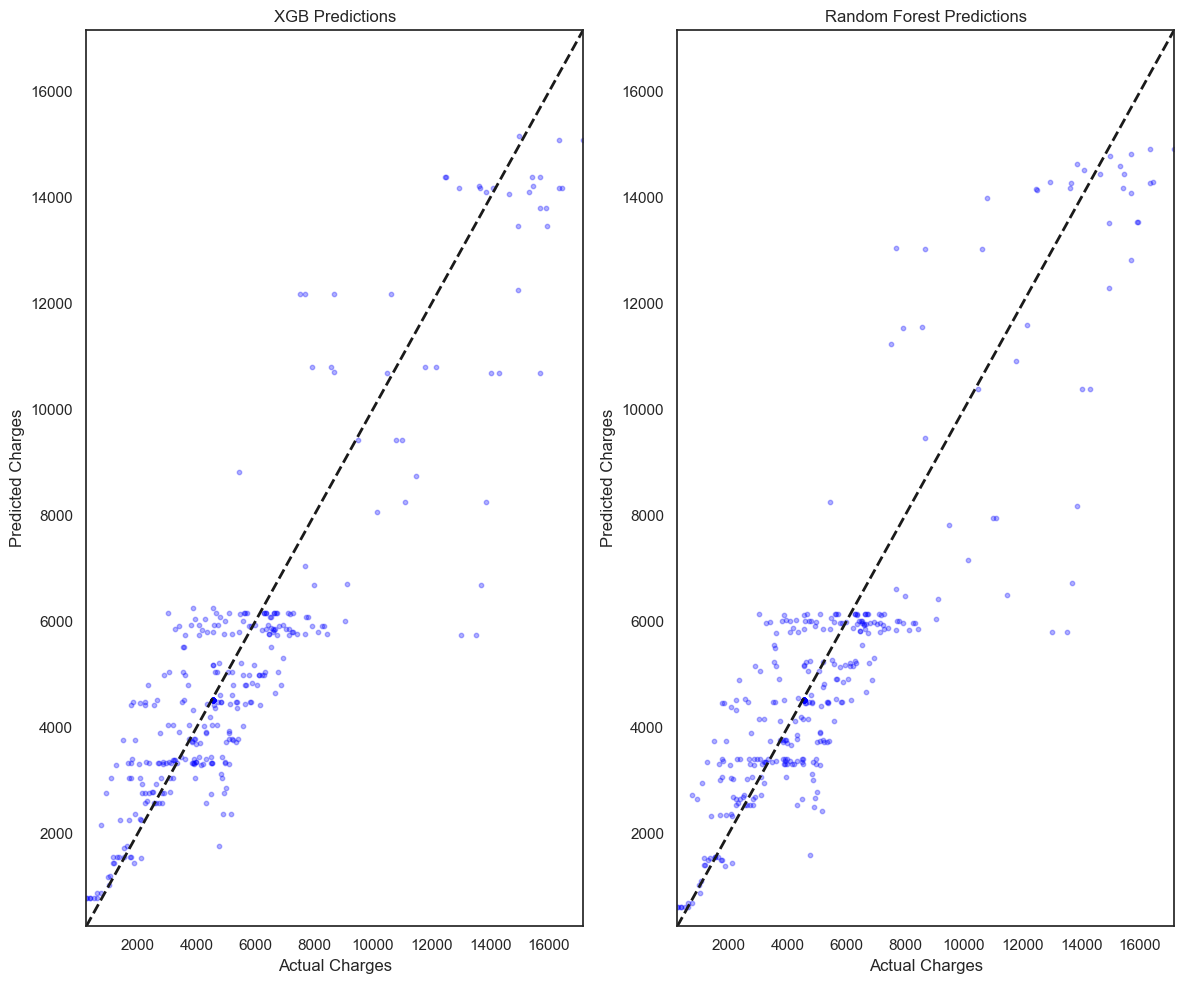

In [189]:
# Plotting actual vs predicted for each model vertically with smaller size
plt.figure(figsize=(12, 10))  

# Get the actual test targets (y_test)
for i, (name, y_pred) in enumerate(predictions.items()):
    plt.subplot(1, 2, i + 1)  # 3 rows, 2 columns
    plt.scatter(y_test, y_pred, alpha=0.3, color='blue', s=10)  # Set color to blue and size to 10
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)  # Diagonal line
    plt.title(f'{name} Predictions')
    plt.xlabel('Actual Charges')
    plt.ylabel('Predicted Charges')
    plt.xlim(y_test.min(), y_test.max())
    plt.ylim(y_test.min(), y_test.max())

plt.tight_layout()
#plt.savefig('Pred_charges_eu_tuned.png')
plt.show()

**Interpretation:**

The scatterplot is plotted to carry out the visual assessment of the two models' performance to see whether the model predicts or underpredicts.

In this graph, each blue dot represents the association between the actual charge and the charge predicted by the XGB model for a given data point. Black line is a perfect prediction. If all of the blue dots fell perfectly on this line, the model's predictions would always be exactly the same as the actual values.

XGB: The plots show significant errors, particularly with mid and higher actual charges. The points are scattered around the dashed black line, indicating a lack of precision. The model struggles with medium actual charges, overpredicting them, suggesting the model accuracy will be low on the range.

Random Forest: The Random Forest model comparatively same with XGB model at lower actual charge. However it struggles to perform well on medium and higher charges with more errors.

In [191]:
# Define XGBoost model
xgb = XGBRegressor(random_state=42)

# Define scoring metrics
scoring = {
    'R²': 'r2',
    'MSE': 'neg_mean_squared_error',
    'MAE': 'neg_mean_absolute_error'
}

# Perform cross-validation
xgb_cv_scores = {}
for metric_name, metric in scoring.items():
    scores = cross_val_score(xgb, X, y, cv=10, scoring=metric)
    xgb_cv_scores[metric_name] = scores
    print(f"XGBoost CV {metric_name} Scores: {scores}")
    print(f"Mean {metric_name}: {np.mean(scores):.3f} (±{np.std(scores):.3f})\n")

XGBoost CV R² Scores: [-0.24477412  0.31048352 -0.52544349  0.84375956  0.48238226  0.53609855
  0.56353781  0.20705929 -0.06922286  0.59260766]
Mean R²: 0.270 (±0.407)

XGBoost CV MSE Scores: [-5449851.47804957  -819144.95767742 -2958064.51492467 -2833208.24408949
 -1453344.31185548  -815036.05187194 -9669030.0218341  -2847714.2453259
 -1261089.11768041 -8544311.40734969]
Mean MSE: -3665079.435 (±3029731.609)

XGBoost CV MAE Scores: [-1665.08619516  -604.2596391  -1112.3900644  -1419.14324581
  -935.51845727  -649.05844609 -1904.61551877 -1287.63763825
  -789.20399763 -2041.55650256]
Mean MAE: -1240.847 (±486.297)



In [192]:
df.shape

(1701, 5)

We can see that out of 10 folds, seven folds yields positive R square. However, 3 scores are negative. It can be seen that there is inconsistency in modelling outcomes.

In [194]:
# Define Random Forest model
rf = RandomForestRegressor(random_state=42)

# Perform cross-validation
rf_cv_scores = {}
for metric_name, metric in scoring.items():
    scores = cross_val_score(rf, X, y, cv=10, scoring=metric)
    rf_cv_scores[metric_name] = scores
    print(f"Random Forest CV {metric_name} Scores: {scores}")
    print(f"Mean {metric_name}: {np.mean(scores):.3f} (±{np.std(scores):.3f})\n")

Random Forest CV R² Scores: [-0.38232468  0.1628084  -0.94207483  0.73417231  0.37655945  0.30174857
  0.53572503  0.0272972  -0.24545764  0.55902611]
Mean R²: 0.113 (±0.486)

Random Forest CV MSE Scores: [ -6052073.29977016   -994582.8610253   -3765975.38403942
  -4820424.09261256  -1750468.94003623  -1226769.37850932
 -10285171.79310467  -3493299.80714477  -1468948.27087344
  -9248623.27308984]
Mean MSE: -4310633.710 (±3153919.212)

Random Forest CV MAE Scores: [-1764.9968135   -649.0347552  -1259.22470484 -1684.49960935
  -966.94390023  -765.47686507 -2018.39107478 -1348.61629935
  -860.8108508  -2135.45537368]
Mean MAE: -1345.345 (±507.433)



We can see that out of 10 folds, seven folds yields positive R square. However, 3 scores are negative. It can be seen that there is instablity in Random Forest Modelling outcome.

### Applying XGBoost and Random Forest on Ireland's dataset

#### Research question: Does crude oil use influence electricity consumption in a given time period in Ireland?"

In [198]:
ireland_data = df[df['Country Name'].isin(['Ireland'])]

In [199]:
ireland_data.isnull().sum()

Country Name                  0
Country Code                  0
Year                          0
Electric Power Consumption    0
Energy use                    0
dtype: int64

In [200]:
ireland_data.shape

(63, 5)

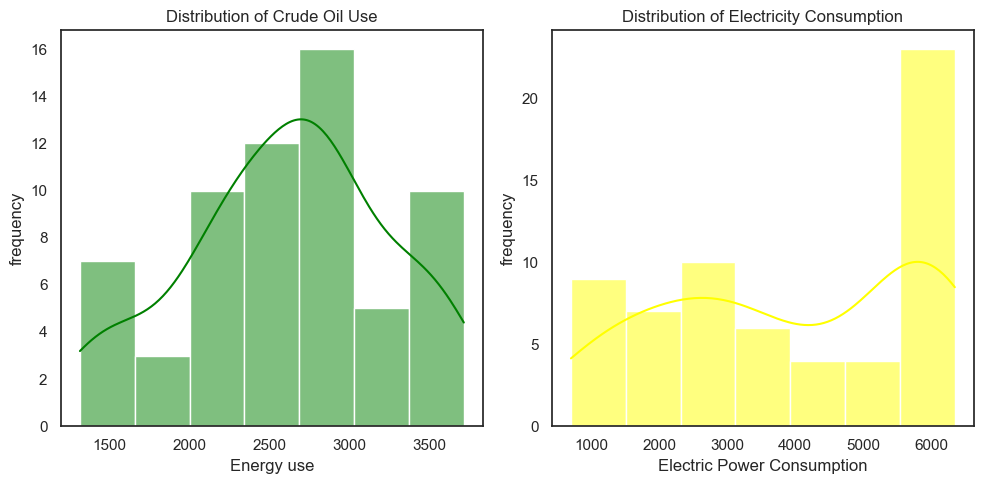

In [201]:
# Set style
sns.set(style="white")

# Plot histograms
plt.figure(figsize=(10, 5))

# Crude Oil Use
plt.subplot(1, 2, 1)
sns.histplot(data=ireland_data, x="Energy use", kde=True, color="green")
plt.title("Distribution of Crude Oil Use")
plt.ylabel('frequency')

# Electricity Consumption
plt.subplot(1, 2, 2)
sns.histplot(data=ireland_data, x="Electric Power Consumption", kde=True, color="yellow")
plt.title("Distribution of Electricity Consumption")
plt.ylabel('frequency')

plt.tight_layout()
plt.savefig('Histograms_IE_ML.png')
plt.show()

We apply XGB and Random Forest because the data does not achieve normality and it has skewed distribution on electric power consumption data.  

In [203]:
# Define features and target variable
X = df[["Energy use"]]  # Independent variable
y = df["Electric Power Consumption"]  # Dependent variable    

# Set up parameter grids for each model
param_grid = {
    'XGB': {
        'n_estimators': [100, 200],
        'learning_rate': [0.05, 0.1],
        'max_depth': [3, 5],
        'subsample': [0.8, 1.0],
        'colsample_bytree': [0.8],
        'gamma': [0, 0.1],
        'reg_lambda': [1, 10]
    },
    'Random Forest': {
        'n_estimators': [50, 100, 200],
        'max_depth': [None, 5, 10]
    }
}

# Initialize results
results = []
predictions = {}

# Define models
models = {
    "XGB": XGBRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42)
}

# Train and tune models
for name, model in models.items():
    grid_search = GridSearchCV(model, param_grid[name], cv=10, scoring='r2', return_train_score=True)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    grid_search.fit(X_train, y_train)
    
    # Get best model and predictions
    best_model = grid_search.best_estimator_
    y_pred = best_model.predict(X_test)
    y_train_pred = best_model.predict(X_train)  # Training predictions
    
    # Calculate metrics
    metrics = {
        'Model': name,
        'Best Parameters': grid_search.best_params_,
        'Best CV R² Score': grid_search.best_score_,
        'Train R²': r2_score(y_train, y_train_pred),  # Training R²
        'Test R²': r2_score(y_test, y_pred),          # Test R²
        'Train MAE': mean_absolute_error(y_train, y_train_pred),  # Training MAE
        'Test MAE': mean_absolute_error(y_test, y_pred),          # Test MAE
        'Train RMSE': np.sqrt(mean_squared_error(y_train, y_train_pred)),  # Training RMSE
        'Test RMSE': np.sqrt(mean_squared_error(y_test, y_pred)),          # Test RMSE
        'Train MSE': mean_squared_error(y_train, y_train_pred),  # Training MSE
        'Test MSE': mean_squared_error(y_test, y_pred)           # Test MSE
    }
    
    results.append(metrics)
    predictions[name] = y_pred

# Create DataFrame
results_df = pd.DataFrame(results)

# Display full results without truncation
pd.set_option('display.max_columns', None)
pd.set_option('display.expand_frame_repr', False)
pd.set_option('display.max_colwidth', None)

print("\nModel Evaluation Results:")
display(results_df)


Model Evaluation Results:


,Model,Best Parameters,Best CV R² Score,Train R²,Test R²,Train MAE,Test MAE,Train RMSE,Test RMSE,Train MSE,Test MSE
0,XGB,"{'colsample_bytree': 0.8, 'gamma': 0, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100, 'reg_lambda': 10, 'subsample': 0.8}",0.791139,0.826683,0.812000,894.995415,1079.096923,1289.709008,1535.047933,1.663349e+06,2.356372e+06
1,Random Forest,"{'max_depth': 5, 'n_estimators': 200}",0.792916,0.851601,0.803201,846.357096,1091.077827,1193.401533,1570.561411,1.424207e+06,2.466663e+06


With small dataset of 63 observations, the project applied ten-fold cross-validation to achieve a reliable outcome, as each test fold in ten-fold CV uses 6 samples, instead of using 12 subsets of data with five folds. The trade-offs can be computationally demanding. 

XGB: The optimal parameters for a tree classification system include a random sample size of 0.8, a learning rate of 0.05 to reduce overfitting, a maximum depth of 3, a total of 100 boosting rounds, and 10 L2 regularization terms. With best parameters, the XGBoost model outperformed the Random Forest model in cross-validation, with a best CV R² score of 0.663447. On the test set, XGBoost showed a slightly higher test R² of 0.877617, indicating a larger variance in the target variable. Both models performed well on the training data and the test dataset, indicating a strong fit to the data.

Random Forest: The optimal parameters for Random Forest include a maximum depth of 5 trees and a total of 200 n_estimators. Random Forest achieved a cross-validated R² of 0.579831 with a test R² score of 0.873828. 

Both XGBoost and Random Forest are strong predictors with high R² scores. XGB receives better performance during cross-validation, slightly higher R² and lower MSE/RMSE on unseen test data.

In [205]:
# Define features and target variable
X = ireland_data[["Energy use"]]  # Independent variable
y = ireland_data["Electric Power Consumption"]  # Dependent variable    

# Set up parameter grids for each model
param_grid = {
    'XGB': {
        'n_estimators': [100, 200],
        'learning_rate': [0.05, 0.1],
        'max_depth': [3, 5],
        'subsample': [0.8, 1.0],
        'colsample_bytree': [0.8],
        'gamma': [0, 0.1],
        'reg_lambda': [1, 10]
    },
    'Random Forest': {
        'n_estimators': [50, 100, 200],
        'max_depth': [None, 5, 10]
    }
}

# Initialize results list with correct columns
results = []
predictions = {}

# Define the models
models = {
    "XGB": XGBRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42)
}

# Train and tune models
for name, model in models.items():
    grid_search = GridSearchCV(model, param_grid[name], cv=5, scoring='r2')
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    grid_search.fit(X_train, y_train)
    
    # Get best model and predictions
    best_model = grid_search.best_estimator_
    y_pred = best_model.predict(X_test)
    
    # Calculate metrics
    metrics = {
        'Model': name,
        'Best Parameters': grid_search.best_params_,
        'Best CV R² Score': grid_search.best_score_,
        'Test R²': r2_score(y_test, y_pred),
        'MAE': mean_absolute_error(y_test, y_pred),
        'MSE': mean_squared_error(y_test, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred))
    }
    
    results.append(metrics)
    predictions[name] = y_pred

# Create DataFrame
results_df = pd.DataFrame(results)

# Display full results without truncation
pd.set_option('display.max_columns', None)
pd.set_option('display.expand_frame_repr', False)
pd.set_option('display.max_colwidth', None)

print("\nModel Evaluation Results with five-folds:")
display(results_df)


Model Evaluation Results with five-folds:


,Model,Best Parameters,Best CV R² Score,Test R²,MAE,MSE,RMSE
0,XGB,"{'colsample_bytree': 0.8, 'gamma': 0, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100, 'reg_lambda': 10, 'subsample': 0.8}",0.739589,0.877617,546.745779,521049.025083,721.837257
1,Random Forest,"{'max_depth': 5, 'n_estimators': 50}",0.706665,0.890964,487.890578,464225.564597,681.341005


We attempt to compare the two cross-validation methods, the XGB model performed less in the CV R square score. The remaining performance metrics are identical in both ten-fold and five-fold cross-validation.

The effect of changing cross-validation methods is prominent on the Random Forest model; all test data performance metrics slightly improved in five-fold cross-validation. 

Therefore, changing the number of folds on the dataset does not have a large effect. 


### Model Evaluation Metrics

In [208]:
# Store results
from sklearn.model_selection import KFold
from tabulate import tabulate

results = []

# Train and evaluate models
for name, model in models.items():
    # Train the model
    model.fit(X_train, y_train)
    
    # Predict on the test set
    y_pred = model.predict(X_test)
    
    # Calculate performance metrics
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    
     # Perform 5-fold cross-validation on training data
    kfold = KFold(n_splits=5, shuffle=True, random_state=42)
    
    # Calculate cross-validation scores
    cv_mae = -cross_val_score(model, X_train, y_train, cv=kfold, 
                             scoring='neg_mean_absolute_error').mean()
    cv_mse = -cross_val_score(model, X_train, y_train, cv=kfold,
                            scoring='neg_mean_squared_error').mean()
    cv_rmse = np.sqrt(cv_mse)
    cv_r2 = cross_val_score(model, X_train, y_train, cv=kfold,
                          scoring='r2').mean()
    
    # Append results to the list
    results.append([name, mae, mse, rmse, r2, cv_mae, cv_mse, cv_rmse, cv_r2])


# Create a DataFrame to display the results
results_df = pd.DataFrame(results, columns=[
    "Model", 
    "Test MAE", "Test MSE", "Test RMSE", "Test R2",
    "CV MAE", "CV MSE", "CV RMSE", "CV R2"
    ])


print(tabulate(results_df, headers='keys', tablefmt='grid', showindex=False))

+---------------+------------+------------------+-------------+-----------+----------+----------+-----------+----------+
| Model         |   Test MAE |         Test MSE |   Test RMSE |   Test R2 |   CV MAE |   CV MSE |   CV RMSE |    CV R2 |
+===============+============+==================+=============+===========+==========+==========+===========+==========+
| XGB           |    723.59  |      1.30864e+06 |    1143.96  |  0.69263  |  655.722 |   993941 |   996.966 | 0.565266 |
+---------------+------------+------------------+-------------+-----------+----------+----------+-----------+----------+
| Random Forest |    522.726 | 584803           |     764.724 |  0.862643 |  599.25  |   732864 |   856.075 | 0.686567 |
+---------------+------------+------------------+-------------+-----------+----------+----------+-----------+----------+


**Interpretation:**

The Random Forest model has lower errors, with a lower MAE, MSE, and RMSE compared to Linear Regression. It also explains a larger proportion of the target variable's variance, approximately 86.3%, compared to Linear Regression's 76.1%, indicating a better fit to the data.

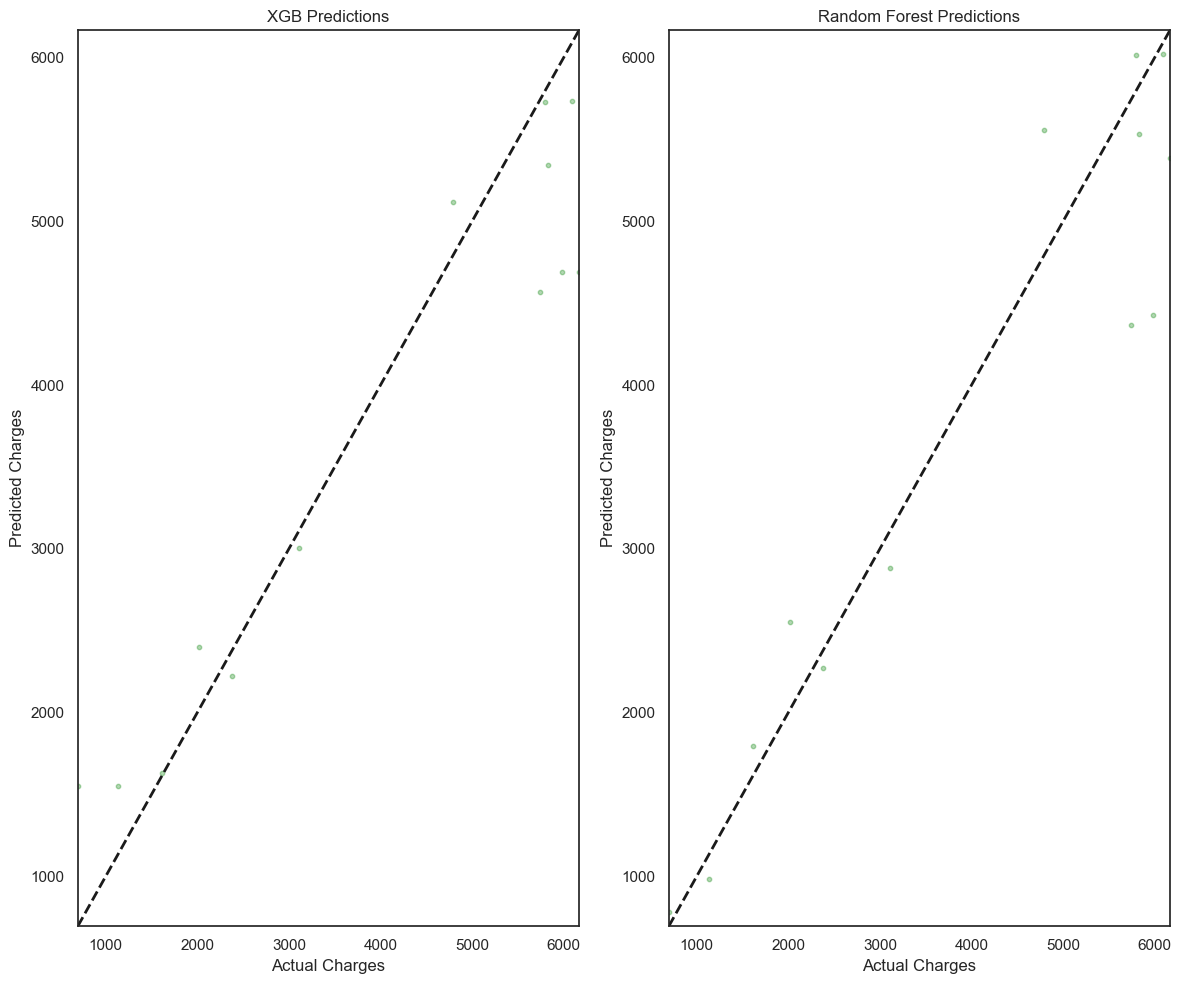

In [210]:
# Plotting actual vs predicted for each model vertically with smaller size
plt.figure(figsize=(12, 10))  # Adjusted size for a 3x2 layout

# Get the actual test targets (y_test)
for i, (name, y_pred) in enumerate(predictions.items()):
    plt.subplot(1, 2, i + 1)  # 3 rows, 2 columns
    plt.scatter(y_test, y_pred, alpha=0.3, color='green', s=10)  # Set color to blue and size to 10
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)  # Diagonal line
    plt.title(f'{name} Predictions')
    plt.xlabel('Actual Charges')
    plt.ylabel('Predicted Charges')
    plt.xlim(y_test.min(), y_test.max())
    plt.ylim(y_test.min(), y_test.max())

plt.tight_layout()
#plt.savefig('pre_charges_ie.png')
plt.show()

**Interpretation:**

XGB model makes errors in predictions, with a positive linear trend as actual charges increase. However, the model has moderate error, underpredicting at higher charges (5000-6000) and closer to actual values (2000), with some spread at lower charges.

Random Forest: The model shows slight accuracy in handling lower actual charges (1000-3000). There are some variability around the ideal line at higher charge at 6000.  

The XGB model appears to perform better visually than the Linear Regression model, particularly for non-linear relationships. The interpretation of these models may be influenced by the size and distribution of the data. 

### Autoregressive Integrated Moving Average (ARIMA)

This project will apply the Autoregressive Integrated Moving Average (ARIMA) model on the energy use of Ireland and Germany. 

Because ARIMA can predict the future trends based on the past observations([DataCampto,n.d](https://www.datacamp.com/tutorial/arima)) 

Before we applied ARIMA model, there are requirements we need to have in the data: 

+ A univariate time series (count or continuous) with at least 50-100 observations
+ If the time series consists of count data, the interval over which the count is taken must remain the same over time
+ If the time series consists of continuous data, the interval between measurements must remain the same over time
+ Data must be presented in a vertical vector (column of data) ([Columbia University,n.d](https://www.publichealth.columbia.edu/research/population-health-methods/box-jenkins-methodology)).

### Data Preparation for ARIMA 

In [214]:
# Filtering Ireland from original DF
ireland = df[df['Country Name'] == 'Ireland']
#removing the old index
ireland.reset_index(drop=True)


,Country Name,Country Code,Year,Electric Power Consumption,Energy use
0,Ireland,IRL,1960,695.043484,1318.812487
1,Ireland,IRL,1961,752.018128,1396.466152
2,Ireland,IRL,1962,838.137550,1412.729677
3,Ireland,IRL,1963,886.193539,1453.962105
4,Ireland,IRL,1964,1041.670301,1522.194973
...,...,...,...,...,...
58,Ireland,IRL,2018,5931.811290,2835.594406
59,Ireland,IRL,2019,5943.044055,2768.262637
60,Ireland,IRL,2020,5978.278094,2659.001525
61,Ireland,IRL,2021,6167.094893,2728.558177


In [215]:
print(f"Ireland_data: {ireland.shape}")

Ireland_data: (63, 5)


Both dataset has a total of 63 observations and five columns. Since the datasets have above 50 observations, we can use the ARIMA model for time series analysis. 

The Energy use variable has a continuous data type in both datasets. The variable is recorded yearly equal interval. The dataset can be fitted into ARIMA model.

In [218]:
#Create a quick dataframe to check datatype and missing value in the data
pd.DataFrame({
    'Ireland_dtype': ireland.dtypes,
    'Ireland_missing': ireland.isnull().sum()
})

,Ireland_dtype,Ireland_missing
Country Name,object,0
Country Code,object,0
Year,int64,0
Electric Power Consumption,float64,0
Energy use,float64,0


No null values are observed in both dataset.

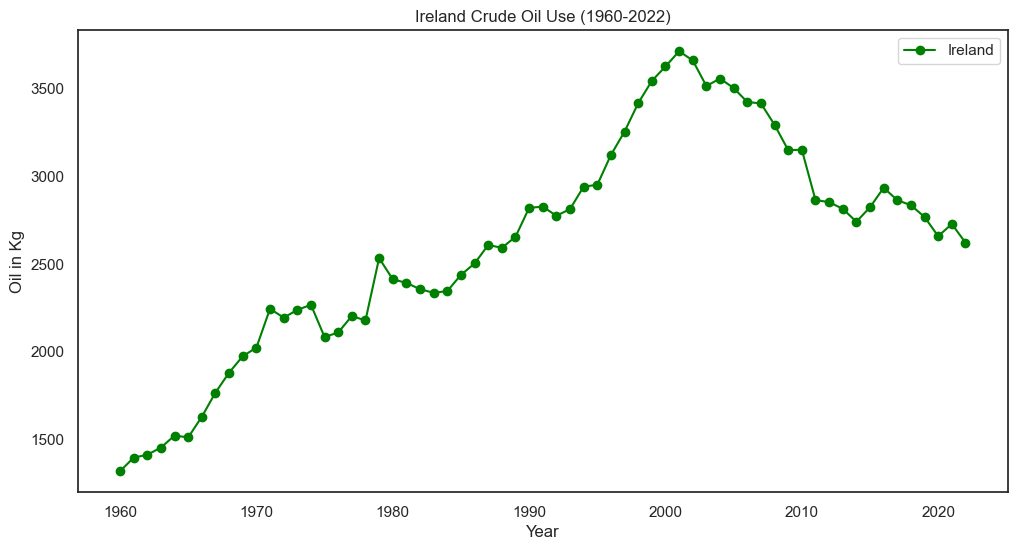

In [220]:
# Plot comparison
plt.figure(figsize=(12, 6))
plt.plot(ireland['Year'], ireland['Energy use'], label='Ireland', color='green', marker='o')
plt.title("Ireland Crude Oil Use (1960-2022)")
plt.xlabel("Year")
plt.ylabel("Oil in Kg")
plt.legend()
plt.savefig('IE_Oil.png')
plt.show()

Line plot is initially created to see the trend of crude oil consumption (energy use) in the dataset. We can see that there are a few spikes in the dataset and data cannot be stationary. However, we can check the stationarity of the dataset by conducting ADF hypothesis testing.

### Plotting boxplots

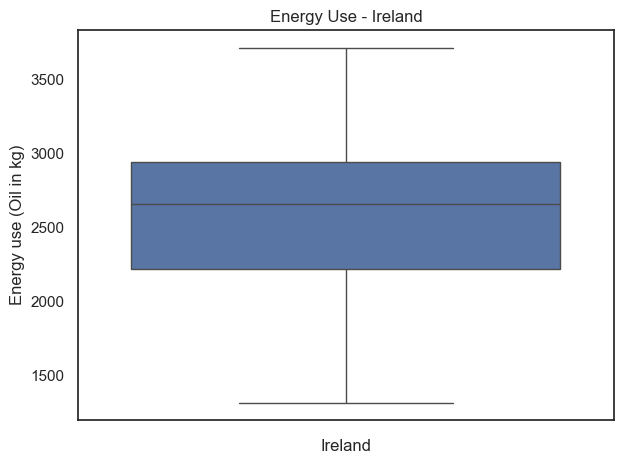

In [223]:
plt.figsize=(8, 5)

# Ireland boxplot (left)
sns.boxplot(data=ireland, y='Energy use')
plt.title('Energy Use - Ireland')
plt.xlabel('Ireland')
plt.ylabel('Energy use (Oil in kg)')

plt.tight_layout()
plt.show()

**Interpretation:**

The box plots provide a statistical summary of crude oil use distributions for Ireland and Germany over a period. The box plots is used to see the outliers and distribution in the dataset. 

Ireland's median crude oil use is around 2600 kg, with the middle 50% falling between 2200 kg (Q1) and 2950 kg (Q3). The whiskers extend from 1300 kg to 3700 kg, indicating the total spread of most data points over the years. There are no apparent outliers on the lower or upper ends, suggesting that while there is variability, there aren't exceptionally high or low years of crude oil consumption for Ireland relative to the overall distribution. 

### Plotting Histograms

Text(0, 0.5, 'Frequency')

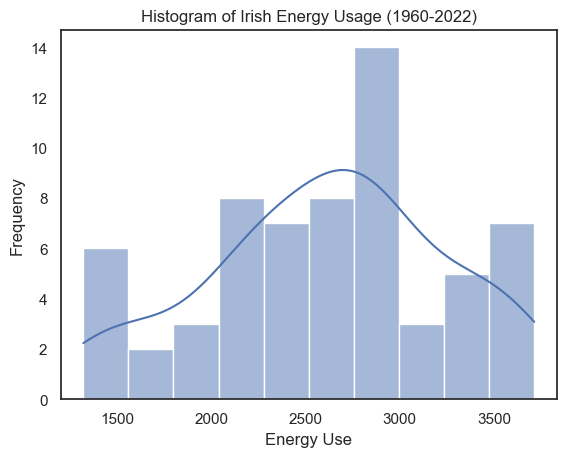

In [226]:
plt.figsize=(12, 5)
# Ireland plot
sns.histplot(ireland['Energy use'], kde=True, bins=10)
plt.title('Histogram of Irish Energy Usage (1960-2022)')
plt.xlabel('Energy Use')
plt.ylabel('Frequency')

**Interpretation:**

The histograms are plotted to see the central tendencies, but also the shape, spread, and frequency of different consumption levels of both countries. 
It provides a visual representation of the distribution of continuous data by grouping data into bins and displaying the frequency of observations within each bin.

The histogram for Ireland's crude oil use shows two prominent peaks, suggesting two distinct periods of consumption between 1960 and 2022. The most frequent range was between 2750 and 3000 kg. The data ranged from 1250 kg to 3750 kg, indicating a considerable spread in crude oil consumption over the years. The distribution seemed right-skewed, suggesting more years with moderately higher consumption than exceptionally low consumption. 

### Checking stationary 

In [229]:
# Import the Augmented Dickey-Fuller test function from statsmodels
from statsmodels.tsa.stattools import adfuller

# --- Context ---
# H₀ (Null Hypothesis): The data has a unit root (non-stationary).
# Small p-value (<0.05) → Reject H₀ → Data is stationary.
# Large p-value → Fail to reject H₀ → Data is non-stationary.

# Perform the ADF test on the energy use data for Ireland
result = adfuller(ireland['Energy use'])  
print('ADF Statistic:', result[0])  
print('p-value:', result[1])  
print('Critical Values:')  
for key, value in result[4].items():  
    print(f'{key}: {value}')  

# Interpret the result
if result[1] < 0.05:  
    print("Reject H₀: Data is stationary (no differencing needed)")  
else:  
    print("Fail to reject H₀: Data is non-stationary (differencing required)")  

ADF Statistic: -2.0782253006031004
p-value: 0.25335996878548167
Critical Values:
1%: -3.548493559596539
5%: -2.912836594776334
10%: -2.594129155766944
Fail to reject H₀: Data is non-stationary (differencing required)


**Interpretation:**

The ADF test is a crucial tool in time series analysis to assess the stationarity of a time series. Stationarity is a key property of data, as it helps in determining the correct order of differencing and identifying model identification issues. Time series models, such as ARIMA, rely on the assumption that the underlying process generating the data is stationary. If a series is non-stationary, it can lead to spurious correlations, unreliable forecasts, and model identification issues.

ADF Statistic result is -2.078. More negative values indicate stronger evidence against the presence of a unit root, which means more evidence for stationarity.

Since p-value is 0.25 which is above 0.05 threshold,  strongly supports null hypothesis. Data is non-stationary data.

Critical Values are threshold values from the Dickey-Fuller distribution at different significance levels (1%, 5%, and 10%). Critical values are compared against ADF statistic to make a decision about the null hypothesis.

+ 1%: -3.54: At a 1% significance level, it would reject the null hypothesis if  ADF statistic is less than -3.54.
+ 5%: -2.91: At a 5% significance level, it would reject the null hypothesis if  ADF statistic is less than -2.91.
+ 10%: -2.59: At a 10% significance level, it would reject the null hypothesis if ADF statistic is less than -2.59.

Since ADF test statistic is greater than all critical values, it fails to reject null hypothesis.

### Feature engineering

In [232]:
ireland.head()

,Country Name,Country Code,Year,Electric Power Consumption,Energy use
819,Ireland,IRL,1960,695.043484,1318.812487
820,Ireland,IRL,1961,752.018128,1396.466152
821,Ireland,IRL,1962,838.137550,1412.729677
822,Ireland,IRL,1963,886.193539,1453.962105
823,Ireland,IRL,1964,1041.670301,1522.194973


In [233]:
# Convert Year column to datetime index
ireland['Year'] = pd.to_datetime(ireland['Year'], format='%Y')
ireland.set_index('Year', inplace=True)

This code demonstrates  to convert the 'Year' column of a 'ireland' DataFrame into a time index for time series analysis. 

The 'ireland['Year']' function is used to convert the 'Year' column to datetime, allowing for time-based indexing, slicing, resampling, time-based plotting, and integration with time series models. 

The 'ireland.set_index('Year', inplace=True) method sets the specified column as the index of the DataFrame, establishing the chronological order of the data. 

This simplifies time-based operations to make time-based selection, aggregation, and analysis. The code also ensures compatibility with time series libraries, as many expect the time variable to be the index of the DataFrame. These steps are crucial for effectively utilizing the time-related functionalities of pandas and other time series analysis libraries for tasks like visualization, analysis, and modeling of energy use data over time.

In [235]:
# First difference & drop NaN
diff_data = ireland['Energy use'].diff().dropna()

The 'Energy use' time series in Ireland is transformed into a stationary series by performing two operations (.diff() and.dropna()). The first difference is used to remove or reduce non-stationarity, specifically trends, which violate the assumption of stationarity required by time series models like ARIMA. This is a common first step in achieving stationarity in a time series. 

The second operation,.dropna(), introduces a NaN value at the beginning of the resulting series due to differencing, ensuring a clean and usable differenced time series for further analysis and modeling. This is necessary to handle missing data and align the differenced series with its time index for further analysis.

In [237]:
result_diff = adfuller(diff_data)
print('ADF Statistic (Differenced):', result_diff[0])
print('p-value (Differenced):', result_diff[1])

if result_diff[1] < 0.05:
    print("Differenced data is stationary (proceed with ARIMA d=1)")
else:
    print("Still non-stationary → try higher-order differencing (d=2)")

ADF Statistic (Differenced): -2.971423183955964
p-value (Differenced): 0.037650674126284596
Differenced data is stationary (proceed with ARIMA d=1)


The Augmented Dickey-Fuller (ADF) test is used again to verify the success of a differencing step in making a time series stationary. This step is crucial as it helps determine the order of integration (d) in the ARIMA model. If the differenced data is stationary (p-value < 0.05), it means first differencing was enough to remove non-stationary components, allowing for the fitting of an ARIMA model with d=1. 

If the differenced data is still non-stationary (p-value >= 0.05), it suggests higher-order differencing is needed or different method of differencing should be applied. The iterative process of checking for stationarity after each differencing step ensures that the data meets the necessary conditions for the ARIMA model. This step is essential for ensuring the data meets the necessary conditions for achieving a stationary time series.

**Interpretation:**

The ADF test statistic on the first-differenced 'Energy use' series is -2.971423183955964, and the p-value is 0.037650674126284596. 

The p-value is below the significance level of 0.05, rejecting the null hypothesis that the time series has a unit root and is non-stationary. 

This results in sufficient statistical evidence to suggest that the first-differenced 'Energy use' data is stationary. To achieve stationarity, the order of integration in the ARIMA model should be set to 1. Analyzing the Autocorrelation Function and Partial Autocorrelation Function of the stationary data will help determine the appropriate orders for the autoregressive and moving average components.

### Plotting ACF and PACF

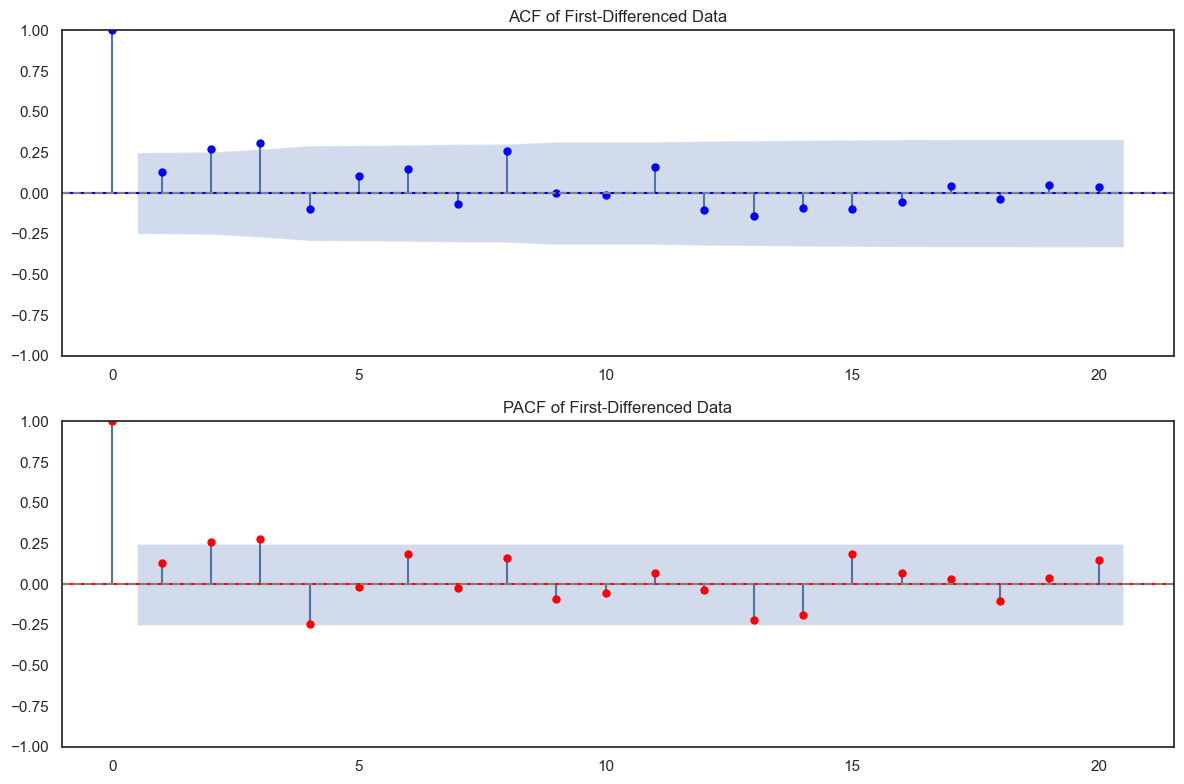

In [265]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# first differenced data
diff_data = ireland['Energy use'].diff().dropna()

# Create subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

# ACF Plot (to identify MA order 'q')
plot_acf(diff_data, lags=20, ax=ax1, title='ACF of First-Differenced Data', color='blue')
ax1.axhline(y=0, linestyle='--', color='gray')

# PACF Plot (to identify AR order 'p')
plot_pacf(diff_data, lags=20, ax=ax2, title='PACF of First-Differenced Data', method='ywm', color='red')
ax2.axhline(y=0, linestyle='--', color='gray')

plt.tight_layout()
plt.show()

**Interpretation:**

The reason why we are plotting acf and pacf plots to identify the correct model order  ([DataCamp,n.d](Source:https://campus.datacamp.com/courses/arima-models-in-python/the-best-of-the-best-models?ex=1)).  

ACF measures the correlation between a data point and its lagged values, considering all intermediate lags. It gives a broad picture of how each observation is related to its past values [(GeeksforGeeks, 2025)](https://www.geeksforgeeks.org/understanding-partial-autocorrelation-functions-pacf-in-time-series-data/)). ACF (Autocorrelation Function) plot reveals a significant positive spike at lag 1, indicating a strong correlation between energy use changes in one period and the previous one. Autocorrelations decay gradually after the initial spike, with some spikes outside the confidence interval at lags 3, 6, and 10. These spikes suggest underlying cyclical patterns or dependencies in the data. 

Partial Autocorrelation Function (PACF) isolates the direct correlation between a data point and a specific lag, while controlling for the influence of other lags. It provides a more focused view of the relationship between a data point and its immediate past [(GeeksforGeeks, 2025)](https://www.geeksforgeeks.org/understanding-partial-autocorrelation-functions-pacf-in-time-series-data/)). PACF plot shows significant positive spikes at lags 1 and 2. Even after accounting for the influence of intermediate lags, the considerable surge at lag 1 keeps that changes in energy use are strongly related to changes in the immediately previous period. After accounting for the effect of the lag 1 change, the large spike at lag 2 indicates that the change in energy use is directly influenced by the change two periods ago.

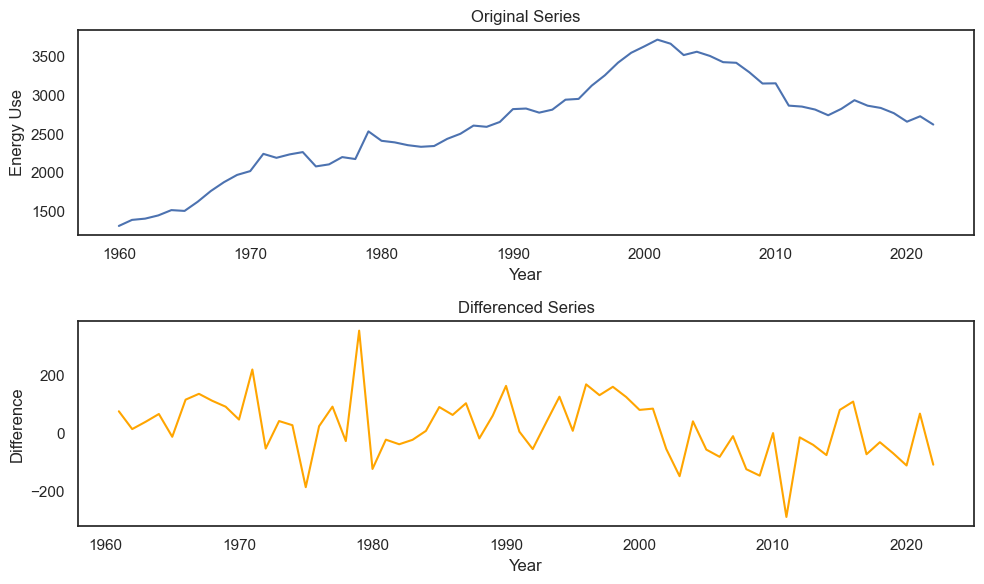

In [268]:
# Create a temporary DataFrame with reset index
temp_df = ireland.reset_index()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6))

# Plot using the Year column
ax1.plot(temp_df['Year'], temp_df['Energy use'], label='Original')
ax1.set_title('Original Series')
ax1.set_xlabel('Year')
ax1.set_ylabel('Energy Use')

# Plot differenced series
ax2.plot(temp_df['Year'].iloc[1:], diff_data, label='Differenced (1st Order)', color='orange')
ax2.set_title('Differenced Series')
ax2.set_xlabel('Year')
ax2.set_ylabel('Difference')

plt.tight_layout()
plt.savefig('IE_Org_Diff.png')
plt.show()

**Interpretation:**

Original Series (Energy Use): The plot shows a long-term upward trend in energy use from the 1960s to the late 2000s. The peak appears around the late 2000s, followed by a decline and stabilization. The original series is non-stationary due to the upward trend.

Differenced Series: The plot shows the first difference in energy use data, plotting the change from the previous year. It removes the upward trend, exhibiting significant volatility and spikes. The differenced series appears stationary, with a more consistent variance over time. To confirm stationarity, statistical tests like the Augmented Dickey-Fuller test are typically performed.

In [271]:
from statsmodels.tsa.arima.model import ARIMA

# ARIMA(p=1, d=1, q=1)
model = ARIMA(ireland['Energy use'], order=(1, 1, 1))  
ireland.index.freq = 'YS'
results = model.fit()
print(results.summary())

                               SARIMAX Results                                
Dep. Variable:             Energy use   No. Observations:                   63
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -374.197
Date:                Mon, 19 May 2025   AIC                            754.393
Time:                        13:05:07   BIC                            760.775
Sample:                    01-01-1960   HQIC                           756.899
                         - 01-01-2022                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.8850      0.135      6.548      0.000       0.620       1.150
ma.L1         -0.7254      0.208     -3.491      0.000      -1.133      -0.318
sigma2      1.021e+04   1439.728      7.089      0.0

**Interpretation:**
  
+ AR(1): One autoregressive term, which means that the current value is forecasted using the value from one year ago.
+ I(1): Integrated of order 1, suggesting that the data was differenced once to establish stationarity.
+ MA(1): One moving average term, which means that the present value is influenced by the error term from one year ago.

ar.L1(0.8850): This coefficient of 0.8850 indicates that the change in energy usage in the current year is highly positively related to the change in energy use the previous year. The fact that the p-value (0.000) is low shows that this association is statistically significant. 

Confidence Interval: The range falls within [0.620, 1.150]: Since the interval does not include 0, the AR(1) term is statistically significant.

ma.L1's coeff: [-0.7254]: There is a moderately strong negative correlation with past error. Past error affects negatively to the today values.

sigma2 (Variance of residual [1.021e+04 (10,210)]: It represents the estimated variance of the model's residuals (noise). High variance indicates that the model cannot account for all the data's variability.

The Ljung-Box test at lag 1 shows no significant evidence of residual correlation in errors one year apart, indicating no autocorrelation. However, to understand the model's randomness, it's essential to examine it for higher lags, as significant autocorrelation at higher lags may indicate the model's inability to capture data dependencies.

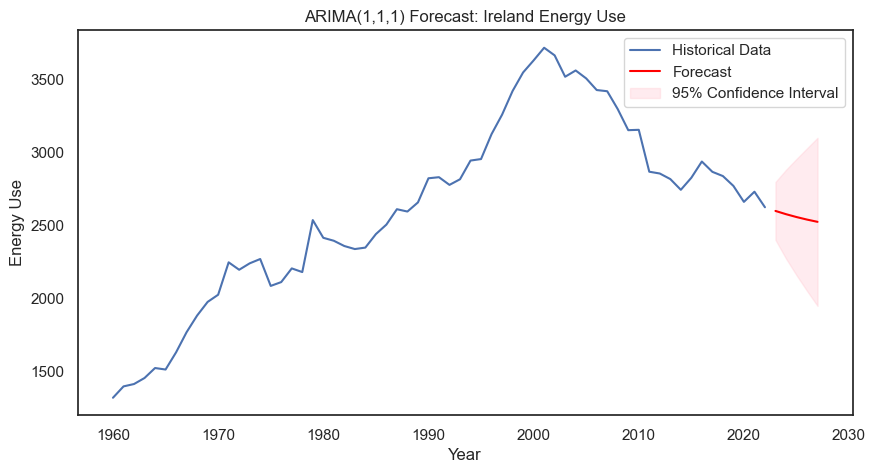

ARIMA(1,1,1) Forecasts:
2023-01-01    2597.046502
2024-01-01    2574.842814
2025-01-01    2555.192679
2026-01-01    2537.802423
2027-01-01    2522.412147
Freq: YS-JAN, Name: predicted_mean, dtype: float64

95% Confidence Intervals:
            lower Energy use  upper Energy use
2023-01-01       2399.035615       2795.057389
2024-01-01       2271.647201       2878.038428
2025-01-01       2157.361885       2953.023473
2026-01-01       2049.979431       3025.625415
2027-01-01       1947.504800       3097.319495


In [274]:
ts_data = ireland['Energy use']  

# Fit ARIMA(1,1,1) model, first differencing
model = ARIMA(ts_data, order=(1, 1, 1))

#fit the model
results = model.fit()

# Generate Forecasts (next 5 years)
forecast_steps = 5
forecast = results.get_forecast(steps=forecast_steps)
forecast_mean = forecast.predicted_mean
conf_int = forecast.conf_int(alpha=0.05)  # 95% confidence intervals

# Create future dates for the forecast
# Date labels for your future forecasts
last_date = ireland.index[-1]
future_dates = pd.date_range(start=last_date + pd.DateOffset(years=1), periods=forecast_steps, freq='YS')
forecast_mean.index = future_dates
conf_int.index = future_dates

# Plot forecasts
plt.figure(figsize=(10, 5))
plt.plot(ireland['Energy use'], label='Historical Data')
plt.plot(forecast_mean, label='Forecast', color='red')
plt.fill_between(conf_int.index, conf_int.iloc[:, 0], conf_int.iloc[:, 1], color='pink', alpha=0.3, label='95% Confidence Interval') 
plt.title('ARIMA(1,1,1) Forecast: Ireland Energy Use')
plt.xlabel('Year')
plt.ylabel('Energy Use')
plt.legend()
plt.show()

print("ARIMA(1,1,1) Forecasts:")
print(forecast_mean)
print("\n95% Confidence Intervals:")
print(conf_int)

**Interpretation**:

The code uses the ARIMA model to analyze and forecast energy use data from a DataFrame, generating predictions for the next 5 years and estimating the uncertainty in those predictions.

We use 95% confidence interval to show the uncertainty of the prediction. If we were to repeat this forecasting process many times, using different samples of historical data, 95% of the predicted value will catch the true future value and 5% will not be able to match with future value.

The historical energy consumption in Ireland from 1960 to early 2020s is depicted, with a peak around 2000 and subsequent decline. The ARIMA(1,1,1) model predicts a gradual decrease in energy consumption from January 1, 2023, to January 1, 2027. The 95% confidence interval indicates a 95% probability of future energy use falling within this range, with increasing uncertainty for distant years.

ARIMA(1,1,1) Predictions (Table): The first table the graph shows the particular point forecast values (the red line) for each year from 2023 to 2027, beginning on January 1st of each year. For example, the projection for January 1, 2023 is around 2597.85.

95% Confidence Intervals (Table): The second table shows the lower and upper bounds of the 95% confidence intervals for each anticipated year. For example, on January 1, 2023, the model forecasts that actual energy use will be between 2399.04 and 2795.09. In 2027, we will notice that the range between the lower and upper boundaries of the confidence interval widens, representing the increased uncertainty in longer-term forecasts.


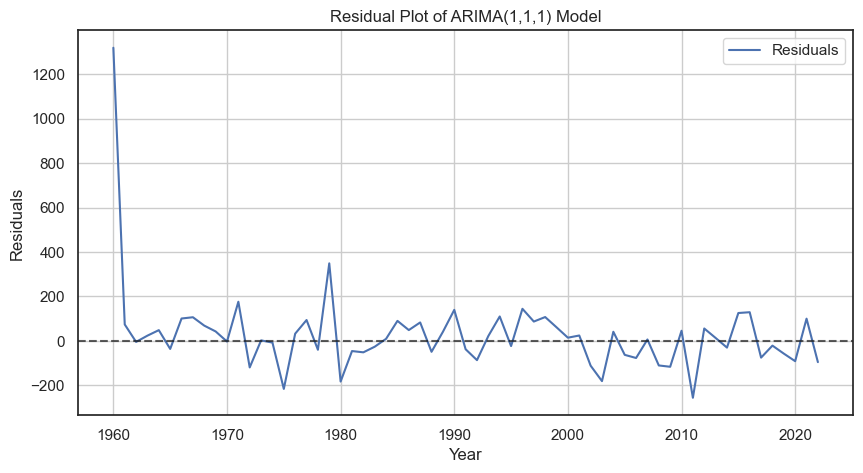

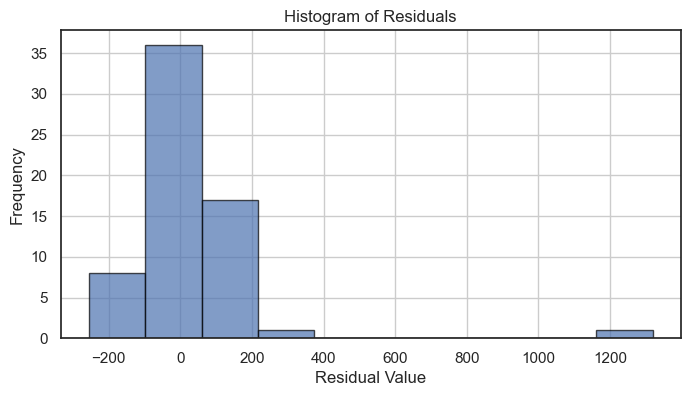

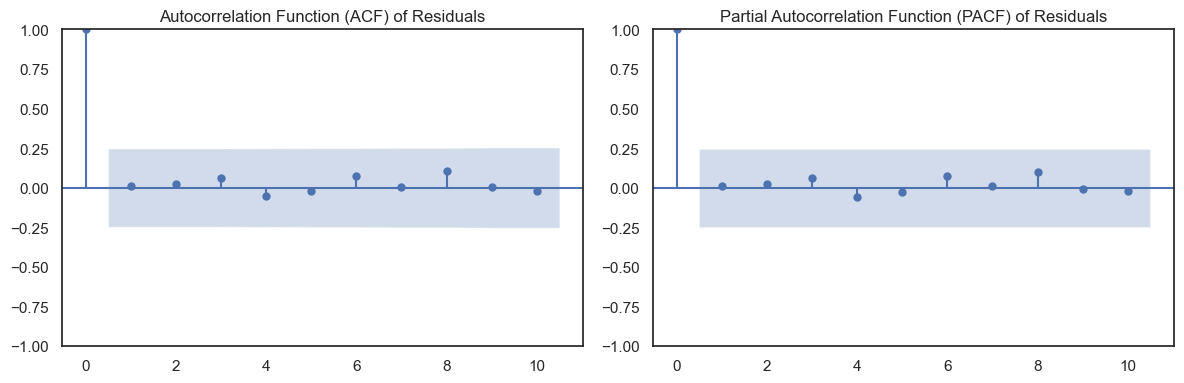

In [277]:
# Fit ARIMA(1,1,1) model
model = ARIMA(ts_data, order=(1, 1, 1))
results = model.fit()

# Get the residuals
residuals = results.resid

# Plot the residuals
plt.figure(figsize=(10, 5))
plt.plot(residuals, label='Residuals')
plt.title('Residual Plot of ARIMA(1,1,1) Model')
plt.xlabel('Year')
plt.ylabel('Residuals')
plt.axhline(0, color='k', linestyle='--', alpha=0.7)  # Add a horizontal line at zero
plt.legend()
plt.grid(True)
plt.show()

# You can also plot the distribution of the residuals (e.g., histogram)
plt.figure(figsize=(8, 4))
plt.hist(residuals, bins=10, edgecolor='black', alpha=0.7)
plt.title('Histogram of Residuals')
plt.xlabel('Residual Value')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

# And check the autocorrelation and partial autocorrelation of the residuals
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(residuals, lags=10, ax=axes[0], title='Autocorrelation Function (ACF) of Residuals')
plot_pacf(residuals, lags=10, ax=axes[1], title='Partial Autocorrelation Function (PACF) of Residuals')
plt.tight_layout()
plt.show()

**Interpretation:**

Residual analysis is a crucial step in evaluating the goodness of fit and the validity of a model's assumptions. It involves examining residuals, which represent the differences between observed and predicted values, to determine if the model has adequately captured the underlying patterns in the time series data.

The residuals are plotted over time, examining for systematic patterns, trends, or seasonality. If these patterns exist, it suggests that the ARIMA(1,1,1) model has not fully captured the underlying structure of the data and might need to be adjusted. Non-constant variance violates one of ARIMA models' assumptions and can affect the reliability of forecasts and confidence intervals.

The Autocorrelation Function (ACF) and Partial Autocorrelation Function (PACF) of residuals are also examined to check for significant correlations between the residuals at different lags. If significant spikes outside the blue confidence intervals indicate that the residuals are autocorrelated, it suggests that the ARIMA(1,1,1) model has not captured all the serial dependence in the data.

Residual Plot: The initial spike in residuals around 1960 suggests the model's inability to fit the early part of the series. Subsequent fluctuations suggest the model is not consistently over- or under-predicting. No obvious trends or seasonal cycles are evident after the initial period.

Residual histogram: The residuals are mostly clustered around zero. However, the distribution is slightly skewed to the right, suggesting underprediction. The non-normal shape, with high residuals close to zero and a large outlier, suggests the residuals may not be perfectly normal.

ACF: The ACF plot reveals a significant spike at lag 1, indicating a statistically significant autocorrelation between a residual and the preceding residual. This suggests the model may not capture all short-term dependencies in the data, potentially leaving some information for further modeling. Autocorrelations mostly fall within the blue shaded region for lags greater than 1.

PACF: The PACF plot demonstrates the correlation between residuals at a specific lag, highlighting the direct effect of a past residual on the current one. A noticeable spike at lag 1 indicates a significant correlation, while partial autocorrelations for lags greater than 1 are mostly within the blue shaded region.

Short-Term reliance: The ACF and PACF plots show significant autocorrelation at lag 1, indicating that the ARIMA(1,1,1) model did not capture all of the residuals' short-term reliance.

Non-Normality in the residuals: The histogram indicates that the residuals are not totally normal, with a slight positive skew and several possible outliers. While normal residuals are not required for ARIMA models to be consistent, substantial deviations might have an impact on statistical inference reliability.


### ARIMA Model with GridSearch 

Testing ARIMA combinations:
ARIMA(0, 1, 0) - AIC:757.29
ARIMA(0, 1, 1) - AIC:758.14
ARIMA(0, 1, 2) - AIC:752.59
ARIMA(1, 1, 0) - AIC:757.55
ARIMA(1, 1, 1) - AIC:754.39
ARIMA(1, 1, 2) - AIC:751.81
ARIMA(2, 1, 0) - AIC:754.64
ARIMA(2, 1, 1) - AIC:754.54
ARIMA(2, 1, 2) - AIC:748.10

Best Order: ARIMA(2, 1, 2) | AIC: 748.10 | Test RMSE: 86.30


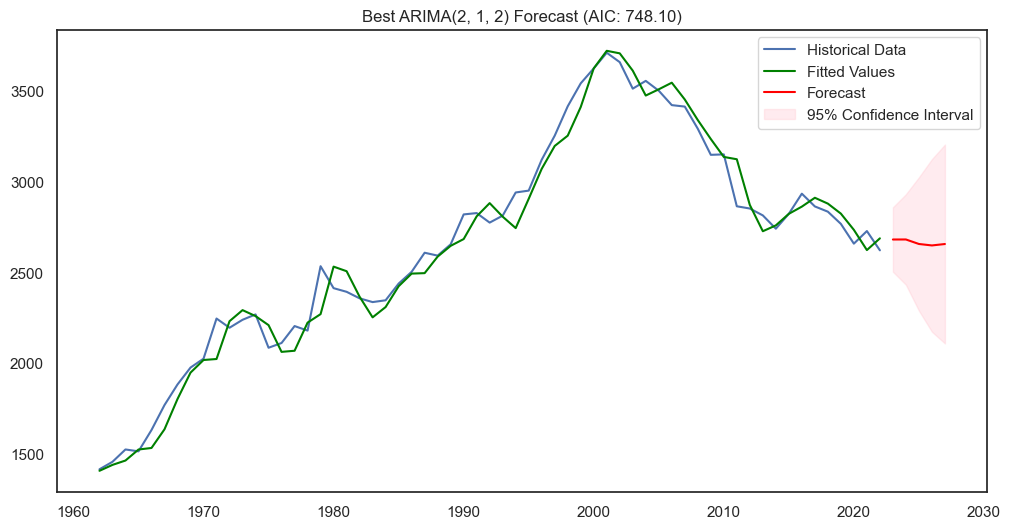

In [289]:
# Modified parameter ranges
ts_data = ireland['Energy use']  

#ignore last five years
train = ts_data[:-5]

#only include last five years
test = ts_data[-5:]

p_range = range(0, 3)
d_range = range(1, 2)  
q_range = range(0, 3)

# ... rest of your grid search code ...
best_aic = np.inf
best_order = None
best_rmse = np.inf


# Grid search
print("Testing ARIMA combinations:")
for p, d, q in product(p_range, d_range, q_range):
    try:
                
        model = ARIMA(ts_data, order=(p, d, q)).fit()
         # Calculate RMSE on test set
        forecast = model.get_forecast(steps=len(test))
        preds = forecast.predicted_mean
        rmse = np.sqrt(mean_squared_error(test, preds))
        
        if model.aic < best_aic:
            best_aic = model.aic
            best_order = (p, d, q)
            best_rmse = rmse
        print(f'ARIMA{p,d,q} - AIC:{model.aic:.2f}')
    except:
        continue

print(f"\nBest Order: ARIMA{best_order} | AIC: {best_aic:.2f} | Test RMSE: {best_rmse:.2f}")


# Fit and forecast with the best model
best_model = ARIMA(ts_data, order=best_order).fit(method='innovations_mle')
forecast = best_model.get_forecast(steps=5)
forecast_mean = forecast.predicted_mean
conf_int = forecast.conf_int()


# Plotting adjusted to remove initialization effects:
plt.figure(figsize=(12,6))

# Skip first 2
plt.plot(ts_data[2:], label='Historical Data') 
plt.plot(best_model.fittedvalues[2:], color='green', label='Fitted Values') 
plt.plot(forecast_mean, label='Forecast', color='red')
plt.fill_between(conf_int.index, conf_int.iloc[:, 0], conf_int.iloc[:, 1], color='pink', alpha=0.3, label='95% Confidence Interval')
plt.title(f'Best ARIMA{best_order} Forecast (AIC: {best_aic:.2f})')
plt.legend()
plt.show()

**Interpretation:**

We conduct the GridSearch to get the optimal order for ARIMA model. This method conducts an automatic search for the optimal ARIMA model order (within the defined ranges) by assessing their AIC on the complete dataset and predicting performance (RMSE) on a held-out test set. 

Before GridSearch, we split the data into train and test data. Training data will be taken ignoring last five years and test data will be taken for last five years. The reason for taking last five years is that the project aims to forecast based on the immediate past. 

Then, we set the range of search to perform GridSearch. 

Once the optimum order is determined, it refits the model on the entire dataset and generates a forecast for the next five periods, as well as a visualization of the results. The first two plot points are skipped to avoid displaying the initial unstable fitted values that occur as a result of the differencing required for stationarity in ARIMA models.

After GridSearch, the best model order with best root mean square error is (2,1,2). 

"Best ARIMA(2, 1, 2)": This indicates that an ARIMA model with an autoregressive order of 2, an integrated order of 1 (meaning the data was likely differenced once for stationarity), and a moving average order of 2 was found to be the "best" according to a specific criterion.

"(AIC: 748.10)": AIC stands for Akaike Information Criteria. It is a statistical metric used to compare various models. A lower AIC suggests a better balance between the model's fit to the data and its complexity (penalizing overfitting). The AIC value (748.10) was most likely the lowest of the models considered, hence the ARIMA(2, 1, 2) order was chosen as the "best."

In [ ]:
# Fit ARIMA(1,1,1) model
model = ARIMA(ts_data, order=(2, 1, 2))
results = model.fit()

# Get the residuals
residuals = results.resid

# Plot the residuals
plt.figure(figsize=(10, 5))
plt.plot(residuals, label='Residuals')
plt.title('Residual Plot of ARIMA(2,1,2) Model')
plt.xlabel('Year')
plt.ylabel('Residuals')
plt.axhline(0, color='k', linestyle='--', alpha=0.7)  # Add a horizontal line at zero
plt.legend()
plt.grid(True)
plt.show()

# You can also plot the distribution of the residuals (e.g., histogram)
plt.figure(figsize=(8, 4))
plt.hist(residuals, bins=10, edgecolor='black', alpha=0.7)
plt.title('Histogram of Residuals')
plt.xlabel('Residual Value')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

# And check the autocorrelation and partial autocorrelation of the residuals
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(residuals, lags=10, ax=axes[0], title='Autocorrelation Function (ACF) of Residuals')
plot_pacf(residuals, lags=10, ax=axes[1], title='Partial Autocorrelation Function (PACF) of Residuals')
plt.tight_layout()
plt.show()

**Interpretation:**

Residual Plot:  Similar to the ARIMA(1,1,1) model, there is a significant positive residual at the start of 1960. After that, the residuals vary around the zero line. The variations may appear less unpredictable when compared to the ARIMA(1,1,1) plot, but there is no significant visual difference. The residuals continue to show no clear indication of persistent trends or seasonal patterns. A few stronger spikes (positive and negative) persist, indicating when the model's prediction error is still present. 

Residual histogram: The histogram shows a clustered distribution around zero, a slight positive skew, and a non-normal shape with a high concentration around zero, a noticeable bar, and a large outlier, similar to the ARIMA(1,1,1) residual histogram.

ACF: The ARIMA(2,1,2) model shows a reduced spike at lag 1, indicating better short-term autocorrelation compared to the ARIMA(1,1,1) model. Autocorrelations for lags greater than 1 remain within the blue shaded region, indicating no significant autocorrelation at longer lags.

PACF: The ARIMA(2,1,2) model effectively addresses short-term direct correlation between consecutive residuals by reducing the significant spike at lag 1, and ensuring partial autocorrelations for lags greater than 1 remain mostly within bounds.

## Sentiment Analysis

In [292]:
sentiment_data = pd.read_csv('energy_posts.csv')

In [294]:
sentiment_data.head(5)

,Post Time,Post Title
0,2025-05-03 20:46:20,Spain’s Power Crisis Shakes Investor Confidence: Goldman Sachs Warns of “Major Energy Policy Shift”
1,2025-05-03 10:30:07,"New research suggests the world may have reached a “tipping point,” making solar power inevitably our primary source of energy"
2,2025-05-03 00:52:54,"Jennifer Granholm: For Real Energy Dominance, We Need the IRA. Saying that the U.S. is striving for energy dominance except in the clean energy sector is like opening a steakhouse and forgetting the meat. What happened to “all of the above”?"
3,2025-05-03 00:40:38,Venezuela Desperate For China To Buy More Oil
4,2025-05-02 23:04:44,"Discover how solar water desalination converts salt water into drinkable water using solar energy, an eco-friendly solution to water scarcity."


In [296]:
#task processing 
import nltk
#to remove stopwords
from nltk.corpus import stopwords

# Download the lexicon
nltk.download("vader_lexicon")
stop_words = set(stopwords.words('english'))

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


the nltk library is imported to carry out natural language processing tasks such as tokenization, sentiment analysis, and text preprocessing.

nltk.download("vader_lexicon") downloads the pre-trained VADER (Valence Aware Dictionary and sEntiment Reasoner) sentiment analysis lexicon

stop_words from English such as a, an the, and from NLTK search is created to filter and remove stop_words.


In [298]:
#regular expression to search for a match in strings 
import re 
# Convert emojis to text
import emoji


def clean_text_data():
    '''
    convert the text to a string
    Remove specific pattern and basic punctuation
    search ...:.. any the patterns in the data and return an empty string
    Remove stop words using lambda function
    Remove emoji and apply the text to lowercase     
    
    '''
    sentiment_data['Post Title'].astype(str)
    sentiment_data['Post Title'] = sentiment_data['Post Title'].apply(
        lambda x: re.sub(r'[^\w\s\']', '', x)  # Keeps words, spaces, and apostrophes
    )
    sentiment_data['Post Title'].apply(lambda x: re.sub(r"...value : .*\.\.\.", '', x))    # Lambda function to remove stop words
    remove_stopwords = lambda text: ' '.join([word for word in text.split() if word not in stop_words])
    # Apply the lambda function to the 'text' column
    sentiment_data['Post Title'] = sentiment_data['Post Title'].apply(remove_stopwords)

    # Function to transform emoji to text only
    def demojize_text(text):
        return emoji.demojize(text)

    # Apply to text column
    sentiment_data['preprocessed_title'] = sentiment_data['Post Title'].apply(demojize_text).str.lower()
  
    # Search for missing values
    sentiment_data.drop(columns=['Post Title'], inplace=True)

    return sentiment_data

clean_text = clean_text_data()

In [300]:
clean_text.head()

,Post Time,preprocessed_title
0,2025-05-03 20:46:20,spains power crisis shakes investor confidence goldman sachs warns major energy policy shift
1,2025-05-03 10:30:07,new research suggests world may reached tipping point making solar power inevitably primary source energy
2,2025-05-03 00:52:54,jennifer granholm for real energy dominance we need ira saying us striving energy dominance except clean energy sector like opening steakhouse forgetting meat what happened
3,2025-05-03 00:40:38,venezuela desperate for china to buy more oil
4,2025-05-02 23:04:44,discover solar water desalination converts salt water drinkable water using solar energy ecofriendly solution water scarcity


Text preprocessing involves cleaning and preparing raw text data for further analysis or model training. Proper text preprocessing can significantly impact the performance and accuracy of NLP models ([GeeksforGeeks,2024](https://www.geeksforgeeks.org/text-preprocessing-for-nlp-tasks/)). 

+ Step 1: Texts are converted to strings because it ensures uniformity. 

+ Step 2: Advanced punctuation is removed to leave only the essential words to focus on the words that have meaning ([Jani,2024](https://medium.com/@jshaik2452/preprocessing-text-data-in-nlp-preparing-your-data-for-success-0fb04ce8456a)).

+ Step 3: Stop words such as [a, an, the, and] are removed from post titles since the words do not carry weight on the meaning. Removing stopwords is to filter out the background noise, letting the important words stand out. 

+ Step 4: Emojis are transformed using the demojize_text() function that converts emojis in text using Python's emoji library. 

+ Step 5: Texts are transformed into lowercase to ensure uniformity. 

### Applying VADER Analysis

VADER (Valence Aware Dictionary and sEntiment Reasoner) is one of the sentiment analysis tools. It is designed to analyze social media text and informal language. It uses a pre-built lexicon of words associated with sentiment values and applies specific rules to calculate sentiment scores.

VADER analysis is applied because it helps in finding the emotional tone of a sentence.

VADER works by analyzing the polarity of words and assigning a sentiment score to each word based on its emotional value. It uses compound score which is a normalized value between -1 and +1, representing the overall sentiment ([GeeksforGeeks,2025](https://www.geeksforgeeks.org/python-sentiment-analysis-using-vader/)):

+ Compound score > 0.05: Positive sentiment
+ Compound score < -0.05: Negative sentiment
+ Compound score between -0.05 and 0.05: Neutral sentiment

In [304]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

analyzer = SentimentIntensityAnalyzer()

def get_vader_scores(text):
    return analyzer.polarity_scores(text)

clean_text['vader_scores'] = clean_text['preprocessed_title'].apply(get_vader_scores)

In [306]:
clean_text.head()

,Post Time,preprocessed_title,vader_scores
0,2025-05-03 20:46:20,spains power crisis shakes investor confidence goldman sachs warns major energy policy shift,"{'neg': 0.272, 'neu': 0.446, 'pos': 0.282, 'compound': 0.0498}"
1,2025-05-03 10:30:07,new research suggests world may reached tipping point making solar power inevitably primary source energy,"{'neg': 0.0, 'neu': 0.788, 'pos': 0.212, 'compound': 0.3612}"
2,2025-05-03 00:52:54,jennifer granholm for real energy dominance we need ira saying us striving energy dominance except clean energy sector like opening steakhouse forgetting meat what happened,"{'neg': 0.0, 'neu': 0.544, 'pos': 0.456, 'compound': 0.9022}"
3,2025-05-03 00:40:38,venezuela desperate for china to buy more oil,"{'neg': 0.247, 'neu': 0.753, 'pos': 0.0, 'compound': -0.3182}"
4,2025-05-02 23:04:44,discover solar water desalination converts salt water drinkable water using solar energy ecofriendly solution water scarcity,"{'neg': 0.0, 'neu': 0.761, 'pos': 0.239, 'compound': 0.5267}"


**Interpretation:**

The code is used to analyze and quantify the sentiment (emotional tone) of preprocessed text data using VADER. 

VADER Sentiment Analyzer returns the dictionary of sentiment values such as negative, neutral, positive, and compound scores. The cleaned text data has 412 rows with 3 columns.

VADER analysis is important to categorize text data into negative, neutral, positive, and compound scores. Because by using these scores, the unsupervised machine learning model will be fit on the data. 

This project tries to answer whether we can identify specific periods when posts tend to be more positive or negative. 

### Research question: "Can we identify specific time periods when posts tend to be more positive or negative?"

##### This project uses compound scores to cluster and predict the specific time period. 

Because using the compound scores can provide negative and positive trends that texts are leading to during the given period. 

### Data preprocessing 

Firstly, compound feature is created from vader_scores using Python's lambda function.

hour and dayofweek features are extracted from clean_text['Post Time'] features using Python's datetime function. 

TF-IDF (Term Frequency-Inverse Document Frequency) vectorization is used in text because unsupervised learning, such as clustering or topic modeling, relies on identifying distinctive words to group similar documents. TF-IDF gives the highest weight to terms that appear frequently in a small number of documents ([Cambridge University Press, 2008](https://nlp.stanford.edu/IR-book/html/htmledition/tf-idf-weighting-1.html)).

TfidfVectorizer uses an in-memory vocabulary (a Python dict) to map the most frequent words to features indices and hence compute a word occurrence frequency (sparse) matrix. The word frequencies are then reweighted using the Inverse Document Frequency (IDF) vector collected feature-wise over the corpus ([scikit-learn,2007-2025](https://scikit-learn.org/stable/auto_examples/text/plot_document_clustering.html)).

Since machine learning models cannot directly apply the text data, post titles are transformed to array. Title_df is created to represent text data from the 'preprocessed_title' column by converting each of the top 500 TF-IDF weighted words into a column.

TF-IDF sparse matrix are converted into a structured DataFrame with feature names.

The project attempts to see the clustering performance difference between unscaled and scaled X data. 

In [312]:
# Extract VADER compoundc score
from sklearn.preprocessing import StandardScaler  # Add this import at the top of your code


clean_text['compound'] = clean_text['vader_scores'].apply(lambda x: x.get('compound'))

# Process post_time
clean_text['Post Time'] = pd.to_datetime(clean_text['Post Time'])
clean_text['hour'] = clean_text['Post Time'].dt.hour
clean_text['day_of_week'] = clean_text['Post Time'].dt.dayofweek

# Process post_title with TF-IDF
tfidf = TfidfVectorizer(max_features=500)  # Limiting features for simplicity
title_features = tfidf.fit_transform(clean_text['preprocessed_title']).toarray()
title_df = pd.DataFrame(title_features, columns=tfidf.get_feature_names_out())

# Combine features
X = pd.concat([clean_text[['compound', 'hour', 'day_of_week']],title_df], axis=1)

# Scale numerical features
#scaler = StandardScaler()
#X_scaled = scaler.fit_transform(X)

In [314]:
X.head()

,compound,hour,day_of_week,10,100,160,20,2022,2024,2025,2030,25,26,30,40,according,across,act,action,administration,advice,agency,agenda,air,allow,already,america,american,americas,amid,analysis,and,announced,another,applications,are,as,australia,average,baby,back,bad,batteries,battery,benefits,better,biden,bidens,big,bill,billion,bills,blackout,boom,boost,breakthrough,britain,build,built,businesses,but,buy,california,call,came,can,canada,capacity,carbon,center,challenges,change,chart,cheap,china,chinas,chinese,chris,clean,cleanenergy,cleaner,cleantech,clear,climate,co2,coal,companies,company,concerns,convert,cost,costs,could,country,credits,crisis,customers,cut,cuts,data,day,days,deal,debate,decision,demand,demands,department,despite,disaster,discover,districts,doe,domestic,dominance,donald,done,drill,drilling,drive,driving,drop,dropped,earth,economic,economy,efficiency,electricity,emergency,emissions,end,energy,environmental,era,eu,europe,european,europes,even,ever,evidence,executive,executives,expected,experts,explore,export,exposed,facility,factories,fall,farms,fast,faster,federal,find,finds,fire,firms,first,five,floating,for,forecasts,former,forward,fossil,founder,france,free,from,fuel,fuels,full,funding,future,futures,gamechanging,gas,generation,generator,geothermal,germany,get,give,glass,global,goals,going,golden,gonna,great,green,greener,grew,grid,gridtied,grip,ground,growing,growth,guarantees,happening,hard,has,he,heat,help,helps,here,high,higher,hits,home,homes,house,household,households,how,hydrogen,idea,impact,important,improved,in,increase,increased,independence,india,industries,industry,innovation,innovative,installing,interconnection,interest,investment,ira,is,isnt,it,its,jobs,judge,keep,keeping,key,kill,killing,know,largest,last,latest,lawmakers,lead,leaders,learn,leaving,left,liberty,lights,like,living,lng,low,lower,made,major,make,making,manufacturing,market,markets,materials,mean,might,million,mission,money,more,most,moving,much,natural,nearly,need,net,never,new,news,no,not,nuclear,offgrid,office,officials,offshore,ohio,oil,one,ontario,operations,orders,our,outlook,over,panels,part,partner,partnership,people,per,percent,plan,plant,plants,point,policies,policy,politics,potential,power,powered,powerful,president,pressure,price,prices,produce,producing,production,programs,project,projects,promised,pump,push,pushes,puts,putting,question,race,real,reality,reckless,record,red,reduce,reducing,reduction,reform,regard,regulation,reliability,reliance,renewable,renewables,repealing,replace,report,republican,republicans,require,research,resource,revolutionizing,right,rise,risk,roughly,rule,rules,runs,rural,russia,russian,sabotage,safer,safety,said,sales,sanctions,save,savings,say,saying,says,secretary,sector,security,see,sell,senate,sent,set,shale,shaping,share,since,smart,software,solar,solution,solutions,some,source,sources,south,southeast,space,spain,spains,speaking,speed,start,state,states,still,stop,storage,strategic,strategy,study,summit,supply,support,survey,sustainability,sustainable,system,systems,taking,tariff,tariffs,tax,tech,technologies,technology,texas,than,that,the,there,these,thing,this,three,time,to,today,top,trade,trading,transition,travel,trump,trumps,turbines,turning,two,types,uk,ukraine,ukraines,un,uncertainty,up,us,use,using,vs,wants,war,waste,water,wave,waves,way,we,week,what,white,why,wind,with,without,wood,work,working,works,world,worlds,would,wright,wrong,xi,year,years,yes,yet,york,you,your
0,0.0498,20,5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.454018,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0

In [316]:
X.shape

(412, 503)

28941.1472001567
5854.513313799929
3745.5387584792297
2896.7507361673747
2498.9646299381384
2138.0643645395758
1917.488540119271
1731.961688306158
1577.3356609143216
1466.5469196316863


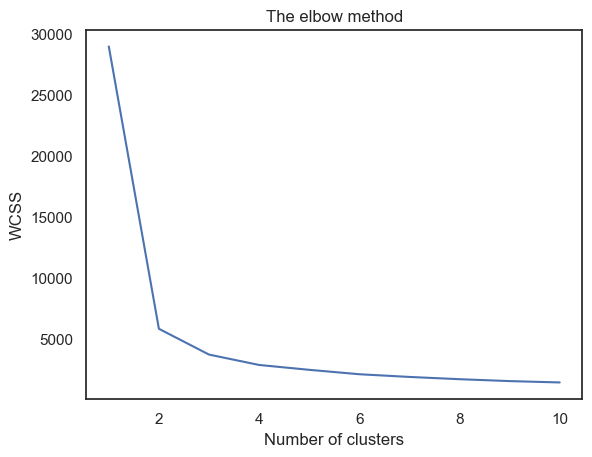

In [318]:
# Finding the optimum number of clusters for k-means classification
from sklearn.cluster import KMeans
wcss = []                  # Declare an array

# Set the loop from the minimum and maximum values
for i in range(1, 11):
    kmeans = KMeans(n_clusters = i, max_iter = 300, n_init = 10, random_state = 0)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)
    print(kmeans.inertia_)
# inertia_float: Sum of squared distances of samples to their closest cluster center.

# Plotting the results onto a line graph, allowing us to observe 'The elbow'
plt.plot(range(1, 11), wcss)
plt.title('The elbow method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')    # within cluster sum of squares
#plt.savefig('elbow_1.png')
plt.show()

**Interpretation:**

This code performs the Elbow Method to determine the optimal number of clusters for K-Means clustering. Based on the graph, the optimal number of cluster is 3 because WCSS drops sharply from 2 to 3 number of clusters from 5000 to 3000). 

Elbow methods is used because it is important for our research question to get when posts tend to be more positive and negative. Elbow method avoids the bias and random cluster chocies.

Text(0.5, 1.0, 'Explained Variance and Cumulative Explained Variance by Principal Components')

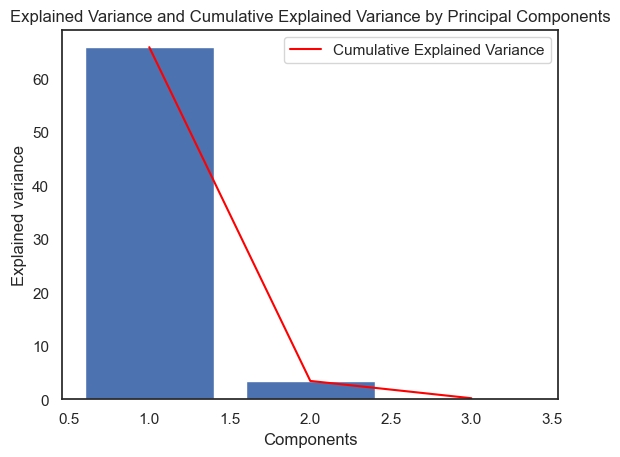

In [320]:
# 4. Apply PCA
pca = PCA(n_components=3)
x_pca = pca.fit_transform(X)  # Fit and transform in one step

plt.bar(range(1,len(pca.explained_variance_ ) + 1), pca.explained_variance_ )
plt.ylabel('Explained variance')
plt.xlabel('Components')
plt.plot(range(1, len(pca.explained_variance_ ) + 1), pca.explained_variance_,
         c = 'red',
         label = "Cumulative Explained Variance")
plt.legend(loc = 'best')
plt.savefig('pca_1.png')
plt.title('Explained Variance and Cumulative Explained Variance by Principal Components')

**Interpretation:**

The Principal Component Analysis (PCA) graph shows the explained variance in a dataset. The first, second, explains a large portion of the total variance, suggesting a strong underlying pattern. The explained variance drops dramatically after the second component, with subsequent components explaining even less.

The cumulative explained variance rises sharply with the first component, and adding more components contributes very little to the total variance explained. 

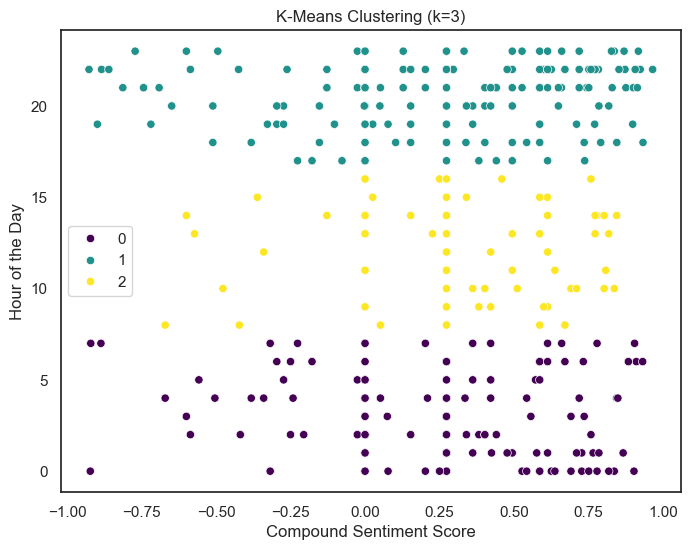

In [324]:
#Based on optimal number of cluster n=3
n_clusters = 3
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10) # Added n_init for future warning
sentiment_data['cluster'] = kmeans.fit_predict(X)

# Visualize the clusters (for 2D data, here we'll use compound and hour)
plt.figure(figsize=(8, 6))
sns.scatterplot(x='compound', y='hour', hue='cluster', data=sentiment_data, palette='viridis')
plt.title(f'K-Means Clustering (k={n_clusters})')
plt.xlabel('Compound Sentiment Score')
plt.ylabel('Hour of the Day')
plt.legend(loc = 'best')
#plt.savefig('clustering_unscaled.png')
plt.show()

**Interpretation:**

The graph shows three clusters on Hour of the Day such as 0-7, 7-17, and 17-23 hours of the day are clustered. Cluster 0, 1, 3 are scattered across different sentiment scores, all clusters having more weight on the positive sentiment scores. 

The least number of energy posts were created between 5-17 hours. People created energy related posts after 17 hours.  

Cluster 2 (Yellow): These points seem to be more prevalent in the more positive sentiment scores (roughly discussions below 0.25) and also appear across various hours.

Key observation on cluster analysis: 

Average compound: The average compound score on the 3 sample cluster ranges from 0.23 to 0.29. It can be suggested that the energy-related discussion have more positive sentiments during the given period.  All clusters have positive average sentiment (compound > 0), suggesting the dataset mild positive sentiment is dominating the data, negative posts are strongly neglected. 

Average hour: energy-related discussions were made at 3 AM for cluster 0. More energy posts that belongs to cluster 1 were made on 20 hours on average. Cluster 2 created energy related discussion around 12:27 PM. 

Average day of week: All clusters average ~2.6 (Tuesday/Wednesday), suggesting weekdays dominate the data. Weekends may be underrepresented or similar to weekdays in sentiment.

In [327]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Instantiate the KMeans models
km = KMeans(n_clusters = 3, random_state=42)

# Fit the KMeans model
km.fit_predict(X)

# Calculate Silhoutte Score
score = silhouette_score(X, km.labels_, metric='euclidean')

# Print the score
print('Silhouetter Score: %.3f' % score)

Silhouetter Score: 0.522


**Interpretation:**

Cluster validation is conducted using the Silhouette Score. It is  a key step in Cluster Analysis, involves evaluating the quality of the outcomes of the clustering process. Proper validation helps avoid common issues such as overfitting or misjudging the optimal number of clusters.

One metric that plays a crucial role in cluster validation is the Silhouette Score. This measure quantifies the quality of clustering, providing an indication of how well each data point resides within its cluster ([CodeSignal,2022](https://codesignal.com/learn/courses/cluster-performance-unveiled/lessons/mastering-cluster-validation-with-silhouette-scores-and-visualization-in-python)). 

The best value is 1 and the worst value is -1. Values near 0 indicate overlapping clusters. Negative values generally indicate that a sample has been assigned to the wrong cluster, as a different cluster is more similar ([scikit-learn,2007-25](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.silhouette_score.html)).

Interpretation on Silhouette score: 

+ Score close to 1: The item is well-matched to its own cluster and poorly matched to neighboring clusters. This would be an indication of strong clustering.

+ Score close to 0: The item is on or very close to the decision boundary between two neighboring clusters. The data point is right at the boundary of the clusters. It's not distinctly in one cluster or another. Here, our clustering model is uncertain about the assignment of these points.

+ Score close to -1: The item is mismatched to its own cluster and matched to a neighboring cluster. This case indicates that we've likely assigned a point to the wrong cluster, as it is closer to the neighboring cluster than its own.

Silhouetter Score: 0.522 for the model suggests that clusters are meaningful but may have some overlap.

### KMeans model evaluation using cross vaildation

In [ ]:
from sklearn.metrics import silhouette_score
from sklearn.model_selection import cross_val_score
from sklearn.cluster import KMeans

# Custom scorer for CV
def silhouette_scorer(estimator, X):
    labels = estimator.fit_predict(X)
    return silhouette_score(X, labels)

kmeans = KMeans(n_clusters=3)
scores = cross_val_score(kmeans, X, cv=5, scoring=silhouette_scorer)

print(f"Silhouette CV Scores: {scores}")
print(f"Mean Score: {np.mean(scores):.3f}")

**Interpretation:**

The cluster quality of Silhouette Score is assessed using the cross-validated evaluation to monitor the model performance and stability across different folds. The results show moderate stability with few inconsistency across five different data subsets. The scores ranges from 0.51 to 0.53.

One subset of data, 0.449 has weaker cluster separation. Model stability scores are around ±0.04 around the mean, suggesting that clusters are reasonably stable but not perfectly consistent.

### K-Mean clustering with Dimensionality reduction

K-Means clustering algorithm groups data points into K clusters based on similarity. It uses Euclidean distance to predict the outcome. On the high-dimensional data plane, in other words, the data with many features, it is hard for K-Means to accurately predict. Because in high-dimensional spaces, data points tend to be sparse, and distances between points become less meaningful.

Therefore, dimensionality reduction techniques such as principal component analysis (PCA), t-SNE, or UMAP are applied to improve model performance. 

Dimensionality reduction is a method for representing a given dataset using a lower number of features while still capturing the original data’s meaningful properties through variable extraction or combination ([Deng et al., 2022](https://www.ibm.com/think/topics/dimensionality-reduction)).  This amounts to removing irrelevant or redundant features, or simply noisy data, to create a model with a lower number of variables. It covers an array of feature selection and data compression methods used during preprocessing ([Jacob, 2025](https://www.ibm.com/think/topics/dimensionality-reduction)). 

In [ ]:
print(f"compound_max: {X['compound'].min()}")
print(f"compound_min: {X['compound'].max()}")
print(f"hour_min: {X['hour'].min()}")
print(f"hour_min: {X['hour'].max()}")
print(f"day_of_week_min: {X['day_of_week'].min()}")
print(f"day_of_week_max: {X['day_of_week'].max()}")

In [ ]:
# 1. Process text with TF-IDF
tfidf = TfidfVectorizer(
    max_features=100,      # Keep top 100 terms
    max_df=0.85,           # Ignore terms in >85% of documents
    min_df=5,              # Ignore terms in <5 documents
    ngram_range=(1, 2)     # Include unigrams and bigrams
)
title_features = tfidf.fit_transform(sentiment_data['preprocessed_title']).toarray()
title_df = pd.DataFrame(title_features, columns=tfidf.get_feature_names_out())

# 2. Combine features (TF-IDF + numerical)
X = pd.concat([sentiment_data[['compound', 'hour', 'day_of_week']], title_df], axis=1)

# 3. Scale ONLY numerical features (leave TF-IDF as-is)
numerical_cols = ['compound', 'hour', 'day_of_week']
X[numerical_cols] = StandardScaler().fit_transform(X[numerical_cols])

# 4. Apply PCA
pca = PCA(n_components=5)
x_pca = pca.fit_transform(X)  # Fit and transform in one step

# 5. Analyze results
explained_variance = pca.explained_variance_ratio_
print(f"Explained variance per component: {explained_variance}")
print(f"Cumulative explained variance: {sum(explained_variance):.2f}")
print(f"Before PCA: {X.shape}, After PCA: {x_pca.shape}")

# Optional: Check feature contributions to PCs
print("\nTop features per principal component:")
for i, component in enumerate(pca.components_):
    top_features_idx = component.argsort()[::-1][:5]  # Indices of top 5 features
    top_features = X.columns[top_features_idx]
    print(f"PC{i+1}: {', '.join(top_features)}")

**Interpretation:**

During the first clustering, we did not apply feature scaling. However, for PCA, scaling is crucial because if one feature is greatly influencing the outcome. Because dimensional reduction using PCA consists of finding the features that maximize the variance. 

If one feature varies more than the others only because of their respective scales, PCA would determine that such a feature dominates the direction of the principal components ([scikit-learn,2007-25](https://scikit-learn.org/stable/auto_examples/preprocessing/plot_scaling_importance.html)).

Therefore, scaling should be carried out for PCA. Only numerical features such as 'compound', 'hour', 'day_of_week' are scaled. 

Before applying pca, the original data contains 412 observations and 103 features. After applying dimensionality reduction, the data becomes 412 observations and 5 features.

Explained variance per component: 

+ Component 1: Explains approximately 26.76% of the total variance.
+ Component 2: Explains approximately 26.12% of the total variance.
+ Component 3: Explains approximately 24.97% of the total variance.
+ Component 4: Explains approximately 1.48% of the total variance.
+ Component 5: Explains approximately 0.95% of the total variance.

The sum of the explained variance of the five principal components, which capture 80% of the total variance in the original 103 features, is 0.8028. By reducing the dimensionality to 5 components, the information is compressed.


In [ ]:
plt.bar(range(1,len(pca.explained_variance_ ) + 1), pca.explained_variance_ )
plt.ylabel('Explained variance')
plt.xlabel('Components')
plt.plot(range(1, len(pca.explained_variance_ ) + 1), pca.explained_variance_,
         c = 'red',
         label = "Cumulative Explained Variance")
plt.legend(loc = 'best')
plt.title('Explained Variance and Cumulative Explained Variance by Principal Components')
plt.savefig('pca_2.png')

**Interpretation:**

The Principal Component Analysis (PCA) graph shows the explained variance in a dataset. The first, second, and third components explain a large portion of the total variance, suggesting a strong underlying pattern. The explained variance drops dramatically after the third component, with subsequent components explaining even less. 

The cumulative explained variance rises sharply with the first component, and adding more components contributes very little to the total variance explained. This suggests that reducing the dimensionality of the dataset significantly with minimal loss of information could be possible. 

In [ ]:
# Finding the optimum number of clusters for k-means classification
from sklearn.cluster import KMeans
wcss = []                  # Declare an array

# Set the loop from the minimum and maximum values
for i in range(1, 11):
    kmeans = KMeans(n_clusters = i, max_iter = 300, n_init = 10, random_state = 0)
    kmeans.fit(x_pca)
    wcss.append(kmeans.inertia_)
    print(kmeans.inertia_)
# inertia_float: Sum of squared distances of samples to their closest cluster center.

# Plotting the results onto a line graph, allowing us to observe 'The elbow'
plt.plot(range(1, 11), wcss)
plt.title('The elbow method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')# within cluster sum of squares
plt.savefig('elbow_2.png')
plt.show()

**Interpretation:**

The elbow plot is a method used to determine the optimal number of clusters for a K-Means clustering algorithm. It plots the Within-Cluster Sum of Squares (WCSS) against the number of clusters, with the goal of finding a point where the rate of decrease sharply changes, forming an "elbow" shape. 

The graph shows a steep decline initially as the number of clusters increases, indicating that adding more clusters reduces within-cluster variance. After around 3 or 4 clusters, the rate of decrease becomes less pronounced, suggesting that adding more clusters doesn't significantly reduce within-cluster variance. The "elbow" point is around 3 or 4 clusters, where the rapid decrease in WCSS levels off. 

Based on this elbow plot, a potential optimal number of clusters for the data could be 3 or 4.

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Instantiate the KMeans models
km = KMeans(n_clusters = 2, random_state=42)

# Fit the KMeans model
km.fit_predict(x_pca)

# Calculate Silhoutte Score
score = silhouette_score(X, km.labels_, metric='euclidean')

# Print the score
print('Silhouetter Score: %.3f' % score)

**Interpretation:**

A silhouette score of 0.216 indicates that the data points are somewhat poorly clustered. The score measures how well each data point fits into its assigned cluster compared to other clusters. 

It ranges from -1 to +1, with +1 indicating the data point is far away from neighboring clusters, 0 indicating the data point is close to the decision boundary between two neighboring clusters, and -1 indicating the data point is likely misclassified and would fit better in a different cluster. 

A score of 0.216 falls into the weak to moderate clustering range, suggesting that the clusters are not very well-separated, borderline, or have a weak clustering structure. Possible reasons for a low silhouette score include overlapping clusters, feature scaling issues, and high dimensionality.

In [ ]:
n_clusters = 3
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10) # Added n_init for future warning
sentiment_data['cluster'] = kmeans.fit_predict(x_pca)


# Visualize the clusters (for 2D data, here we'll use compound and hour)
plt.figure(figsize=(8, 6))
sns.scatterplot(x='compound', y='hour', hue='cluster', data=sentiment_data, palette='viridis')
plt.title(f'K-Means Clustering (k={n_clusters})')
plt.xlabel('Compound Sentiment Score')
plt.ylabel('Hour of the Day')
#plt.savefig('K-means_final.png')
plt.show()

**Interpretation:**

The visualization shows three clusters based on compound sentiment and hour of the day. 

The visualization suggests that positive sentiment might be more common in the morning, while both positive and negative/neutral sentiment are present throughout the day. The overlap between cluster 1 and cluster 0 suggests weak clustering, which aligns with the silhouette score. The visualization suggests that K-Means with k=3 has identified potential groupings based on compound sentiment and hour of the day.

In [ ]:
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans

# Custom scorer for CV
def silhouette_scorer(estimator, X):
    labels = estimator.fit_predict(X)
    return silhouette_score(X, labels)

kmeans = KMeans(n_clusters=3)
scores = cross_val_score(kmeans, X, cv=5, scoring=silhouette_scorer)

print(f"Silhouette CV Scores: {scores}")
print(f"Mean Score: {np.mean(scores):.3f}")

**Interpretation:**

We can validate the stability of KMeans by using cross vaildation.   

Silhouette CV Scores: [0.1669, 0.1998, 0.2043, 0.2410, 0.2200]: the overall mean score of 0.206 suggests weak to moderate clustering quality.

In [ ]:
# Custom scorer for CV
def silhouette_scorer(estimator, X):
    labels = estimator.fit_predict(X)
    return silhouette_score(X, labels)

kmeans = KMeans(n_clusters=3)
scores = cross_val_score(kmeans, X, cv=5, scoring=silhouette_scorer)

print(f"Silhouette CV Scores: {scores}")
print(f"Mean Score: {np.mean(scores):.3f}")

### Sentiment Analysis using Bag of Words Vectorization Approach

Bag of Words is a technique for extracting features from text data for machine learning tasks, such as text classification and sentiment analysis. This is important because machine learning algorithms cannot process textual data. 

A Bag of Words is based on the occurrence of words in a document. The process starts with finding the vocabulary in the text and measuring their occurrence. It is called a bag because the order and structure of words are not considered, just their occurrence. ([DataCamp,2024](https://www.datacamp.com/tutorial/python-bag-of-words-model)).

Bag of Words with Naive Bayes Machine learning model is used to carry out text classification and sentiment analysis in this project. 

Since VADER analysis has limitations as it may not interpret niche terms such as desalination. The advantage of using BoW approach is that it learns from the vocabulary of our own data. If our posts use "energy politics" frequently for negativity, BoW will detect it.

In [ ]:
sentiment_data = pd.read_csv('energy_posts.csv')

In [ ]:
sentiment_data.head()

In [ ]:
#Applying Stop Words
# Download the lexicon
nltk.download("vader_lexicon") 
stop_words = set(stopwords.words('english'))

In [ ]:
import re 
import emoji # Discarding ?. "", '',
import string


def clean_text_data():
    sentiment_data['Post Title'].astype(str)
    sentiment_data['Post Title'] = sentiment_data['Post Title'].apply(
        lambda x: re.sub(r'[^\w\s\']', '', x))  # Keeps words, spaces, and apostrophes
    
    sentiment_data['Post Title'] = sentiment_data['Post Title'].apply(lambda x: re.sub(r'\.\.\.value : .*\.\.\.:\.|\'s|[,":]', '', x))    # Lambda function to remove stop words
    remove_stopwords = lambda text: ' '.join([word for word in text.split() if word not in stop_words])
    # Apply the lambda function to the 'text' column
    sentiment_data['Post Title'] = sentiment_data['Post Title'].apply(remove_stopwords)

    # Function to transform emoji to text only
    def demojize_text(text):
        return emoji.demojize(text)

    # Apply to text column
    sentiment_data['preprocessed_title'] = sentiment_data['Post Title'].apply(demojize_text).str.lower()
  
    # Search for missing values
    sentiment_data.drop(columns=['Post Title'], inplace=True)

    return sentiment_data

clean_text = clean_text_data()

### Preprocessing on Text for VADAR Analysis

Text preprocessing involves cleaning and preparing raw text data for further analysis or model training. Proper text preprocessing can significantly impact the performance and accuracy of NLP models ([GeeksforGeeks,2024](https://www.geeksforgeeks.org/text-preprocessing-for-nlp-tasks/)). 

Step 1: Texts are converted to strings because it ensures uniformity. 

Step 2: Advanced punctuation is removed to leave only the essential words to focus on the words that have meaning ([Jani,2024](https://medium.com/@jshaik2452/preprocessing-text-data-in-nlp-preparing-your-data-for-success-0fb04ce8456a)).

Step 3: Stop words such as [a, an, the, and] are removed from post titles since the words do not carry weight on the meaning. Removing stopwords is to filter out the background noise, letting the important words stand out. 

Step 4: Emojis are transformed using the demojize_text() function that converts emojis in text using Python's emoji library. 

Step 5: Texts are transformed into lowercase to ensure uniformity. 

In [ ]:
clean_text.head()

In [ ]:
# Create SentimentIntensityAnalyzer object
sent_analyzer = SentimentIntensityAnalyzer()

# function label_output labels the output based on compound
def label_output(compound):
  
  polarity = "neutral"

  if(compound['compound'] >= 0.05):
    polarity = "positive"

  elif(compound['compound'] <= -0.05):
    polarity = "negative"

  return polarity


# Function sentiment analyzes the text and returns the compound
def sentiment(text):
  compound =  sent_analyzer.polarity_scores(text)
  return label_output(compound)


sentiment_data["sentiment"] = sentiment_data["preprocessed_title"].apply(sentiment)
sentiment_data.head(10)
sentiment_data['Words'] = sentiment_data["preprocessed_title"].apply(lambda x: len(x.split()))
sentiment_data.head()
sentiment_data.shape

**Interpretation:**

Object containing the pre-trained lexicon and methods needed to analyze the sentiment of text is created to use the sentiment analysis capabilities provided by NLTK. 

The purpose of the label_output function to categorize raw sentiment scores by setting thresholds (>= 0.05 for positive, <= -0.05 for negative) of compound scores. The function converts the scores into discrete categories makes the results easier to understand and use for tasks such as categorization (positive, negative, or neutral), aggregation (Count number of positive, negative, and neutral words), and visualization to see the percentage and distribution of each categories.

The function called sentiment(text) carries out VADER analysis and get the polarity scores. Then, using lambda function, the scores are calculated the number of words in each preprocessed title and stores these counts in a new feature as "Words". A feature "Words" is created to visualize the word count by sentiment. 

In [ ]:
# Count the number of occurrences of each sentiment
sentiment_counts = sentiment_data['sentiment'].value_counts()

# Sort for better readability (optional, but often helpful)
sentiment_counts = sentiment_counts.sort_values(ascending=False)

# Create a horizontal bar chart
plt.figure(figsize=(8, 6))
sns.barplot(x=sentiment_counts.values, y=sentiment_counts.index, palette='viridis')

# Add data labels directly to the bars (Tufte's emphasis on direct labeling)
for index, value in enumerate(sentiment_counts.values):
    plt.text(value, index, f' {value} ({value/sum(sentiment_counts)*100:.1f}%)', va='center')

# Minimize chartjunk - remove unnecessary elements
plt.xlabel('Number of Occurrences', fontsize=12)
plt.ylabel('Sentiment', fontsize=12)
plt.title('Sentiment Distribution', fontsize=14)
sns.despine() # Remove spines (top and right borders)

plt.tight_layout()
#plt.savefig('sentiment distribution.png')
plt.show()

**Interpretation:**

The bar chart shows that the positive category dominates the data. Out of 412 observations, over 276 sentiments belong to positive. 

17.2% of sentiment are within neutral sentiment. The least frequent sentiment is negative, with only 65 records.

**Interpretation for visualization:**

Edward Tufte's visual display of quantitative information is applied. Instead of using pie chart, we used bar chart to distinguish the amount of neutral, negative and positive categories.  

Edward Tufte's principles:

+ Clear, precise, and efficient.
+ Show data variation, not design variation.
+ Maximize the data-ink ratio.
+ Erase non-essential "chartjunk."
+ Use appropriate scales and labeling.

To adhere to Tufte's principles for effective data visualization, the plot maximizes the Data-Ink Ratio as bar charts have a higher data-ink ratio than pie charts. 

Secondly, we reduce non-data ink by using spines (sns.despines()) to reduce non-data ink. The reason for removing non-data ink is to motivate the viewers' focus on the main graphics and data on the graph and avoid drawing the attention to irrelevant elements.

The plot starts with zero baseline on y-axis to avoid graphical distortion. For example, a bar chart that starts the y-axis at 90 instead of zero can make an increase which is actually small seem bigger.

Third Edward Tufte's principle is applied to minimize Chartjunk, which means excessive or redundant decoration. The pain white background is used to simplfiy the visualization ([GeeksforGeeks, 2024](https://www.geeksforgeeks.org/mastering-tuftes-data-visualization-principles/)).

The plot gives emphasis on the data variation using bar lengths, which represents the variation in the sentiment counts. 

Direct Labeling: we added the exact counts and percentages directly to the bars using plt.text(). Tufte emphasizes direct labeling to avoid the reader having to visually estimate values from the axes.

Finally, we provide the context of the data with main title, y-axis label, and x-axis label.

In [ ]:
# Plot the relationship between word count and sentiment

g = sns.FacetGrid(sentiment_data, col="sentiment", height=4, aspect=1)
g.map(sns.histplot, "Words", kde=True, color='skyblue')
g.set_axis_labels("Word Count", "Frequency")
g.set_titles(col_template="{col_name} sentiment")
plt.tight_layout()
#plt.savefig('sentiment distribution_1.png')
plt.show()

**Interpretation:**

The image displays three histograms illustrating the distribution of "Word Count" for different sentiment categories: "neutral Sentiment," "positive Sentiment," and "negative Sentiment." 

The neutral sentiment has a heavily skewed distribution towards shorter word counts, with the frequency highest for texts with few words. 

Positive sentiment has a more spread-out distribution, with a prominent peak in the lower word count range and higher word counts up to 40 words. 

Negative sentiment has multiple peaks, suggesting it can be expressed with varying text lengths. 

The strong skew towards short word counts for neutral sentiment might indicate that it is often expressed through simple statements or a lack of strong sentiment words. The more spread-out distributions for positive and negative sentiment suggest they can be conveyed with more variability in text length. There is no single "ideal" length for sentiment, as both positive and negative sentiments can occur across a wider range of text lengths.

**Interpretation for visualization:**

The plot applies Edward Tufte's principles to achieve effecitve data visualization. 

+ Maximize Data-Ink Ratio: Within ink and white background, the plot maximize the data-ink ratio to display the curves and histograms.
  
+ Show Data Variation: The primary data variation is focused by using height of histogram bars and shape of the density curves. No 3D effects, shading, or overly decorative elements are applied to achieve simple visualization.

+ Clear and Direct Labeling: Each subplot has given a clear title indicating the sentiment category.Tufte emphasizes direct labeling to avoid the reader having to visually estimate values from the axes.  The x-axis is labeled "Word Count," and the y-axis is labeled "Frequency" to make the viewer  understand what each axis represents.

+ Integration of Different Visual Elements: Histograms and kde density curves is applied to aid the viewers in visualizing different shape of histograms.

In [ ]:
# Pre-Prcoessing and Bag of Word Vectorization using Count Vectorizer
from sklearn.feature_extraction.text import CountVectorizer
from nltk.tokenize import RegexpTokenizer

token = RegexpTokenizer(r'[a-zA-Z0-9]+')
cv    = CountVectorizer(stop_words = 'english',ngram_range = (1, 1),tokenizer = token.tokenize)
text_counts = cv.fit_transform(sentiment_data['preprocessed_title'])

text_counts

In [ ]:
#Splitting the data into trainig and testing
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(text_counts, sentiment_data['sentiment'], test_size=0.30, random_state=5)

In [ ]:
text_counts.shape, X_train.shape, X_test.shape, Y_train.shape, Y_test.shape

**Interpretation:**

text_counts data has 412 observations and 2040 features. 

Training Data:

X_train: Training data has 288 observation and 2040 features.

after applying CountVectorizer, text data has been transformed into a matrix with 2040 features. Each feature represents a unique word (or token, based on tokenizer and ngram_range) found across all 412 titles, after stop word removal. 2040 is the size of your vocabulary.

Y_train: 288 training samples with 1-D shape

Test Data

X_test:  This indicates that testing dataset (X_test) contains 124 samples wiht 2040. 

Y_test: 124 samples with 1 D array. 

In [ ]:
# Training the model
from sklearn.naive_bayes import MultinomialNB
MNB = MultinomialNB()
MNB.fit(X_train, Y_train)

# Calculating the accuracy score of the model
from sklearn import metrics
predicted = MNB.predict(X_test)
accuracy_score = metrics.accuracy_score(predicted, Y_test)
print("Accuracuy Score: ",accuracy_score)

**Interpretation:**

The Multinomial Naive Bayes (MultinomialNB) model is applied to classify text because it is suitable for classification with discrete features (e.g., word counts for text classification). The multinomial distribution normally requires integer feature counts. However, in practice, fractional counts such as tf-idf may also work ([scikit-learn,2007-25](https://scikit-learn.org/stable/modules/generated/sklearn.naive_bayes.MultinomialNB.html)).

62.10% accuracy for a sentiment analysis task with three classes suggests that there is a significant error rate of around 38%. Factors specific to MultinomialNB include feature representation, assumption of Naive Bayes, data size, and class distribution. To improve the model,  more advanced text preprocessing, incorporating n-grams, using TF-IDF weighting, tuning hyperparameters, exploring other models, and conducting error analysis could be applied. 

In [ ]:
print(sentiment_data['sentiment'].value_counts())  # classes are imbalanced

In [ ]:
from sklearn.metrics import classification_report

model = MultinomialNB(alpha=0.7)  # You can adjust alpha
model.fit(X_train, Y_train)

# Step 5: Predict and evaluate
y_pred = model.predict(X_test)
print(classification_report(Y_test, y_pred))

**Interpretation:**

The model performs best on positive sentiment, with high precision and recall. However, it struggles with negative and neutral sentiments, with lower precision, recall, and f1-scores. 

Positive Sentiment: The category has highest model performance with high precision, recall and f1 scores, which means that it is easier for model to learn.

Negative Sentiment: The recall is higher than the precision, indicating that the model accurately detects a reasonable number of true negative cases while wrongly labeling others as negative.

Neutral Sentiment: Both precision and recall are low, showing that the model has trouble correctly detecting neutral cases and being confidence in its predictions of "neutral."

The model's performance on the majority class has a significant impact on overall metrics. The overall accuracy of 61% indicates the model is correct more often than random chance, but there is still a considerable error rate. 

Precision: It is its ability to identify only the relevant data points ([Will,2024](https://builtin.com/data-science/precision-and-recall)). The precision for negative, neutral, and positive instances is 0.30, 0.43, and 0.79 respectively, indicating that only 30%, 43%, and 79% of predicted instances are true.

Recall: It is a model’s ability to find all the relevant cases within a data set([Will,2024](https://builtin.com/data-science/precision-and-recall)). The model correctly identified 53% of negative instances, 41% of neutral instances, and 68% of positive instances with a recall of 0.53, 0.41, and 0.68 respectively.

f1 score: F1 score can be interpreted as a harmonic mean of the precision and recall, where an F1 score reaches its best value at 1 and worst score at 0([scikit-learn,2007-25](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.f1_score.html)). Positive sentiment has good f1 score with 0.75. It is hard to classify negative and neutral sentiment for model.

In [ ]:
from sklearn.metrics import confusion_matrix

# Get class labels
classes = np.unique(Y_test)

# Generate and plot
cm = confusion_matrix(Y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=classes,
            yticklabels=classes)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix with alpha (0.7)')
plt.savefig('confusion Matrix_3.png')
plt.show()

The model excels at predicting positive sentiment with largest number of correctly identified occurrences (58). The model struggles the most with neutral sentiment, properly classifying only 9 of 22 actual neutral instances (3 predicted as negative and 10 as positive). There are also numerous misclassifications for negative and positive thoughts. Five actual negative occurrences were predicted as positive, whereas eighteen actual positive examples were predicted as negative.

### Adjusting alpha value

In [ ]:
model = MultinomialNB(alpha=0.9)  
model.fit(X_train, Y_train)

# Step 5: Predict and evaluate
y_pred = model.predict(X_test)
print(classification_report(Y_test, y_pred))

In [ ]:
from sklearn.metrics import confusion_matrix

# Get class labels
classes = np.unique(Y_test)

# Generate and plot
cm = confusion_matrix(Y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes,
            yticklabels=classes)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix with alpha (0.9)')
plt.savefig('confusion Matrix_2.png')
plt.show()

We can see that adding more alpha values did not change the confusion matrix performance.

### Optimization on code performance

In [ ]:
import time
from datetime import timedelta

# Start total execution timer
total_start_time = time.time()

# Define features and target variable
X = ireland_data[["Energy use"]]  # Independent variable
y = ireland_data["Electric Power Consumption"]  # Dependent variable    

# Set up parameter grids for each model
param_grid = {
    'XGB': {
        'n_estimators': [100, 200],
        'learning_rate': [0.05, 0.1],
        'max_depth': [3, 5],
        'subsample': [0.8, 1.0],
        'colsample_bytree': [0.8],
        'gamma': [0, 0.1],
        'reg_lambda': [1, 10]
    },
    'Random Forest': {
        'n_estimators': [50, 100, 200],
        'max_depth': [None, 5, 10]
    }
}

# Initialize results list with correct columns
results = []
predictions = {}
timing_data = []

# Define the models
models = {
    "XGB": XGBRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42)
}

# Train and tune models
for name, model in models.items():
    model_start_time = time.time()
    
    print(f"\nStarting {name} training...")
    
    grid_search = GridSearchCV(model, param_grid[name], cv=5, scoring='r2')
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    # Time just the model fitting
    fit_start = time.time()
    grid_search.fit(X_train, y_train)
    fit_time = time.time() - fit_start
    
    # Get best model and predictions
    best_model = grid_search.best_estimator_
    y_pred = best_model.predict(X_test)
    
    # Calculate metrics
    metrics = {
        'Model': name,
        'Best Parameters': grid_search.best_params_,
        'Best CV R² Score': grid_search.best_score_,
        'Test R²': r2_score(y_test, y_pred),
        'MAE': mean_absolute_error(y_test, y_pred),
        'MSE': mean_squared_error(y_test, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred)),
        'Training Time (s)': fit_time,
        'Total Model Time (s)': time.time() - model_start_time
    }
    
    results.append(metrics)
    predictions[name] = y_pred
    timing_data.append({
        'Model': name,
        'Training Time': str(timedelta(seconds=fit_time)),
        'Total Time': str(timedelta(seconds=time.time() - model_start_time))
    })
    
    print(f"Completed {name} in {time.time() - model_start_time:.2f} seconds")

# Create DataFrames
results_df = pd.DataFrame(results)
timing_df = pd.DataFrame(timing_data)

# Calculate total execution time
total_time = time.time() - total_start_time

# Display full results without truncation
pd.set_option('display.max_columns', None)
pd.set_option('display.expand_frame_repr', False)
pd.set_option('display.max_colwidth', None)

print("\n" + "="*50)
print(f"Total Execution Time: {timedelta(seconds=total_time)}")

In [ ]:
import time
from datetime import timedelta
import psutil
import os

def train_and_evaluate_model(model_name, model, param_grid, X, y):
    """Train and evaluate a single model with full performance metrics"""
    print(f"\n{'='*50}")
    print(f"Training {model_name} Model")
    print(f"{'='*50}")
    
    # Initialize performance tracking
    process = psutil.Process(os.getpid())
    metrics = {'Model': model_name}
    
    # Memory and CPU before training
    mem_before = process.memory_info().rss / (1024 ** 2)  # MB
    cpu_before = psutil.cpu_percent(interval=1)
    
    # Time the entire process
    start_time = time.time()
    
    # Split data
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    # Grid Search with timing
    grid_start = time.time()
    grid_search = GridSearchCV(model, param_grid, cv=5, scoring='r2', n_jobs=-1)
    grid_search.fit(X_train, y_train)
    metrics['GridSearch Time'] = time.time() - grid_start
    
    # Get best model
    best_model = grid_search.best_estimator_
    
    # Prediction timing
    pred_start = time.time()
    y_pred = best_model.predict(X_test)
    metrics['Prediction Time'] = time.time() - pred_start
    
    # Calculate metrics
    metrics.update({
        'Best Parameters': grid_search.best_params_,
        'Best CV R²': grid_search.best_score_,
        'Test R²': r2_score(y_test, y_pred),
        'MAE': mean_absolute_error(y_test, y_pred),
        'MSE': mean_squared_error(y_test, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred)),
        'Training Samples': len(X_train),
        'Test Samples': len(X_test)
    })
    
    # Resource usage
    metrics.update({
        'CPU Usage (%)': psutil.cpu_percent(interval=1) - cpu_before,
        'Memory Delta (MB)': (process.memory_info().rss / (1024 ** 2)) - mem_before,
        'Total Time (s)': time.time() - start_time
    })
    
    return metrics, y_pred

# Main execution
if __name__ == "__main__":
    # Load your data
    # ireland_data = pd.read_csv(...)
    X = ireland_data[["Energy use"]]
    y = ireland_data["Electric Power Consumption"]
    
    # Define models and parameters
    models = {
        "XGBoost": {
            "model": XGBRegressor(random_state=42),
            "params": {
                'n_estimators': [100, 200],
                'learning_rate': [0.05, 0.1],
                'max_depth': [3, 5],
                'subsample': [0.8, 1.0]
            }
        },
        "Random Forest": {
            "model": RandomForestRegressor(random_state=42),
            "params": {
                'n_estimators': [50, 100, 200],
                'max_depth': [None, 5, 10]
            }
        }
    }
    
    # Train each model separately
    all_results = []
    predictions = {}
    
    for name, config in models.items():
        metrics, y_pred = train_and_evaluate_model(
            name,
            config["model"],
            config["params"],
            X, y
        )
        all_results.append(metrics)
        predictions[name] = y_pred
    
    # Create and display results
    results_df = pd.DataFrame(all_results)
    
    # Format display
    pd.set_option('display.max_columns', None)
    pd.set_option('display.width', 1000)
    
    print("\nFinal Performance Metrics:")
    display(results_df[['Model', 'Best CV R²', 'Test R²', 'MAE', 
                       'Total Time (s)', 'CPU Usage (%)', 'Memory Delta (MB)']])
    
    print("\nDetailed Timing:")
    display(results_df[['Model', 'GridSearch Time', 'Prediction Time', 'Training Samples']])
    
    print("\nBest Parameters:")
    display(results_df[['Model', 'Best Parameters']])